In [4]:
# Бібліотека для роботи з масивами і математичними операціями
import numpy as np
# Бібліотека для роботи з таблицями (DataFrame)
import pandas as pd
# Бібліотека для побудови графіків
import matplotlib.pyplot as plt
# Надбудова над matplotlib для статистичних графіків
import seaborn as sns

# Встановлюємо стиль графіків: білий фон із сіткою
sns.set_theme(style="whitegrid")
# Підвищуємо чіткість графіків
plt.rcParams["figure.dpi"] = 110

# Шлях до CSV-файлу, завантаженого в Colab
CSV_PATH = "AirlinePassengerSatisfaction.csv"
# Зчитуємо файл у таблицю DataFrame
df = pd.read_csv(CSV_PATH)

# Виводимо розмір таблиці: (кількість рядків, кількість колонок)
print("Розмір датасету:", df.shape)
# Показуємо перші 5 рядків таблиці
df.head()

Розмір датасету: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
# Виводимо типи даних і кількість непорожніх значень у кожній колонці
df.info()

# Заголовок блоку про пропуски
print("\n--- Пропущені значення ---")
# Рахуємо кількість пропусків (NaN) у кожній колонці
missing = df.isna().sum()
# Залишаємо лише колонки, де пропуски є
missing = missing[missing > 0]
# Для кожної такої колонки виводимо кількість пропусків і їх частку у відсотках
for col, cnt in missing.items():
    print(f"  {col}: {cnt} ({cnt / len(df) * 100:.2f}%)")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

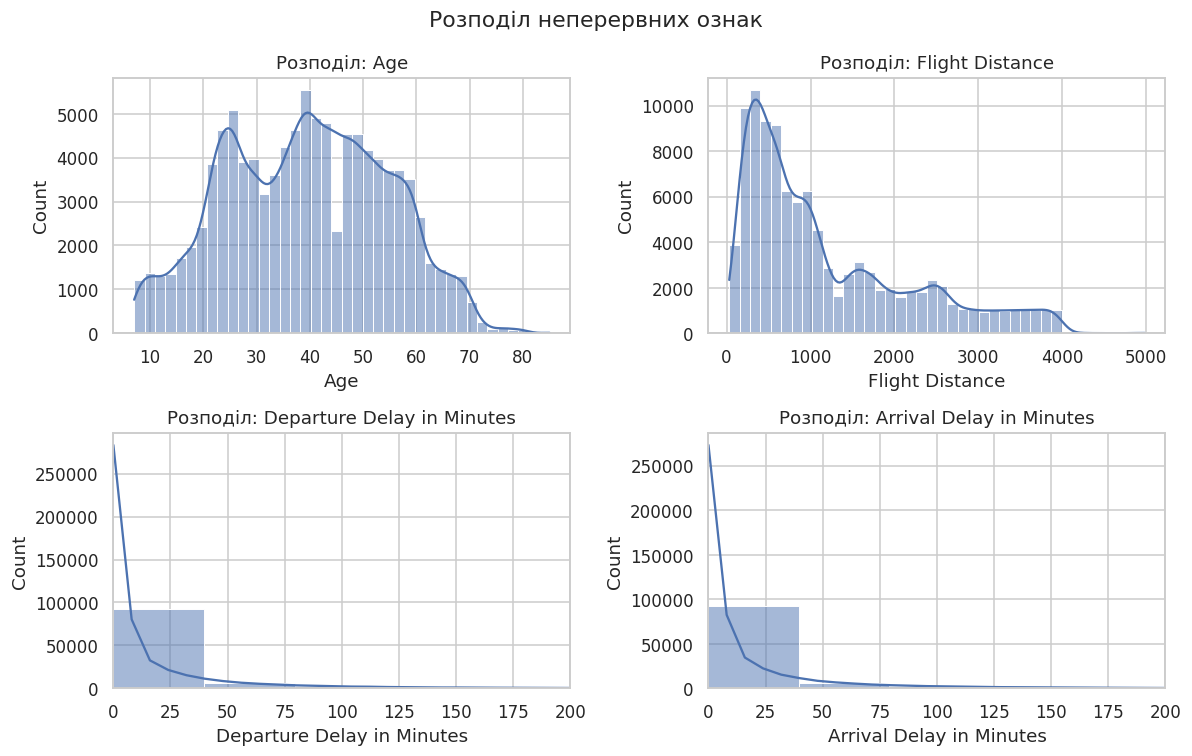

In [6]:
# Неперервні числові ознаки: вік, дистанція, дві затримки
num_features = ["Age", "Flight Distance",
                "Departure Delay in Minutes", "Arrival Delay in Minutes"]

# Створюємо сітку 2 x 2 для чотирьох графіків
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
# Проходимо по графіках і ознаках одночасно
for ax, col in zip(axes.ravel(), num_features):
    # Гістограма (40 стовпців) з KDE-кривою, що згладжує форму розподілу
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax, color="#4C72B0")
    # Заголовок графіка з назвою ознаки
    ax.set_title(f"Розподіл: {col}")
    # Для затримок обмежуємо вісь X до 200 хв, щоб було видно основну масу значень
    if "Delay" in col:
        ax.set_xlim(0, 200)
# Загальний заголовок усієї фігури
fig.suptitle("Розподіл неперервних ознак")
# Вирівнюємо відступи між графіками
fig.tight_layout()
# Відображаємо графіки
plt.show()

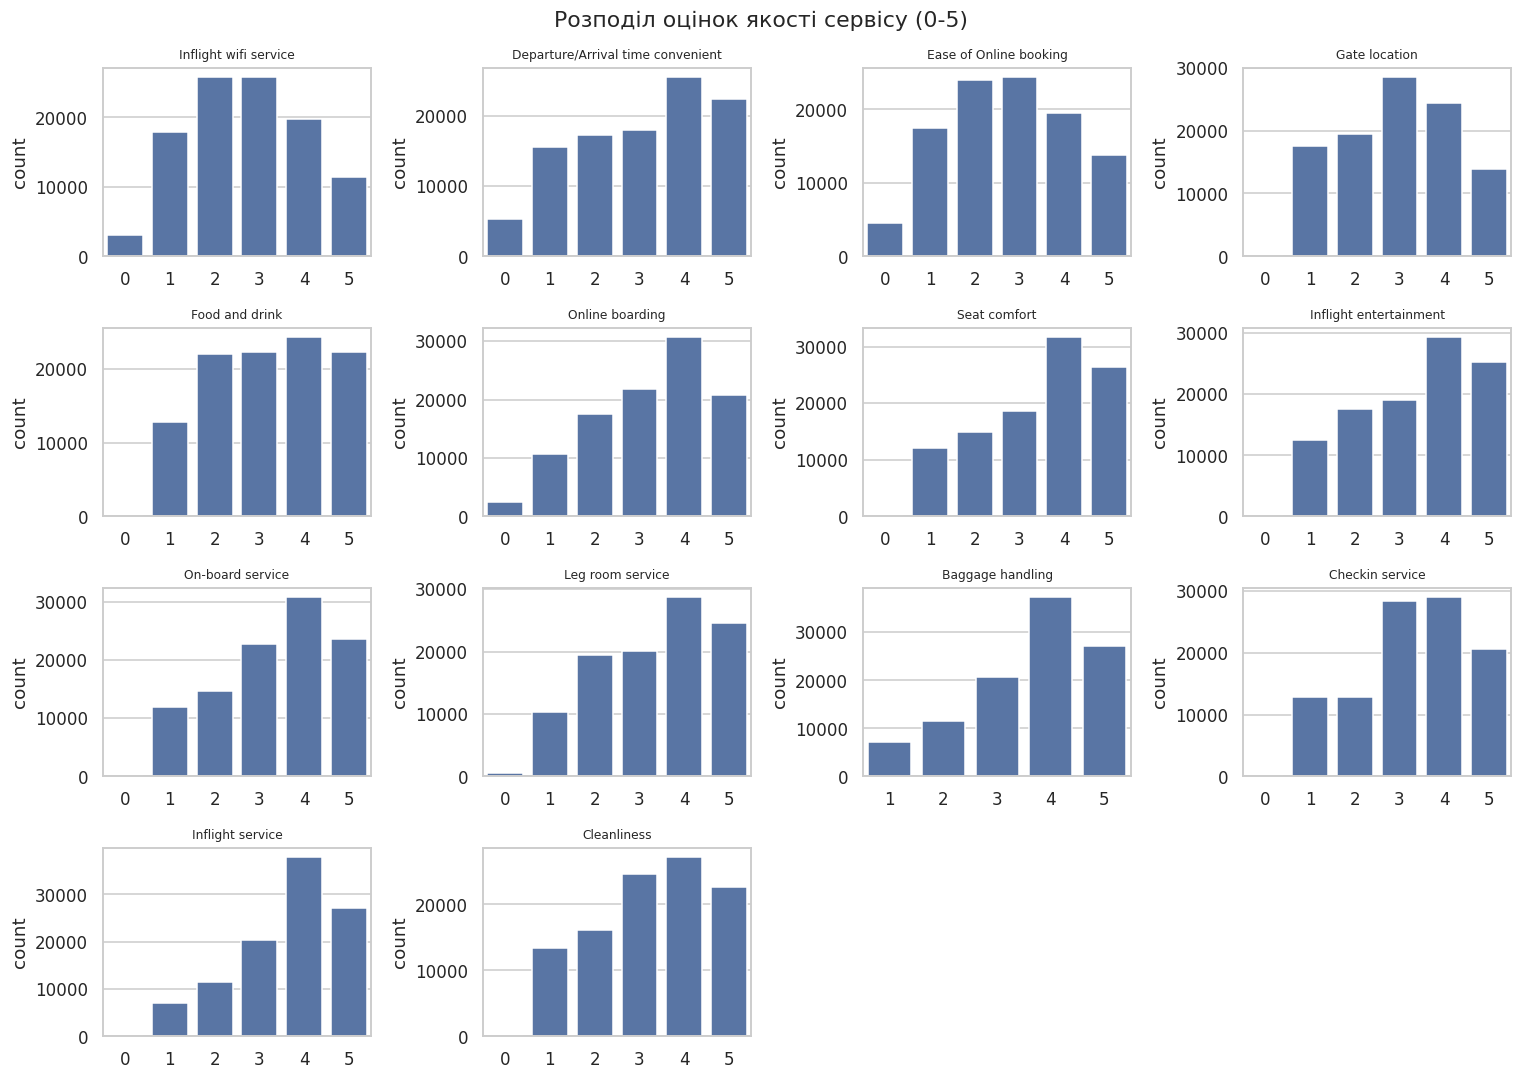

In [7]:
# Список 14 порядкових ознак якості сервісу (оцінки від 0 до 5)
service_features = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink",
    "Online boarding", "Seat comfort", "Inflight entertainment",
    "On-board service", "Leg room service", "Baggage handling",
    "Checkin service", "Inflight service", "Cleanliness",
]

# Сітка 4 x 4 (16 місць для 14 графіків)
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
# Для кожної ознаки будуємо стовпчикову діаграму кількості кожної оцінки
for ax, col in zip(axes.ravel(), service_features):
    # Кількість пасажирів, що поставили кожну оцінку 0-5
    sns.countplot(x=df[col], ax=ax, color="#4C72B0")
    # Назва ознаки дрібним шрифтом
    ax.set_title(col, fontsize=8)
    # Прибираємо підпис осі X, щоб не захаращувати графік
    ax.set_xlabel("")
# Два зайві порожні графіки вимикаємо
for ax in axes.ravel()[len(service_features):]:
    ax.axis("off")
# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Розподіл оцінок якості сервісу (0-5)")
fig.tight_layout()
plt.show()

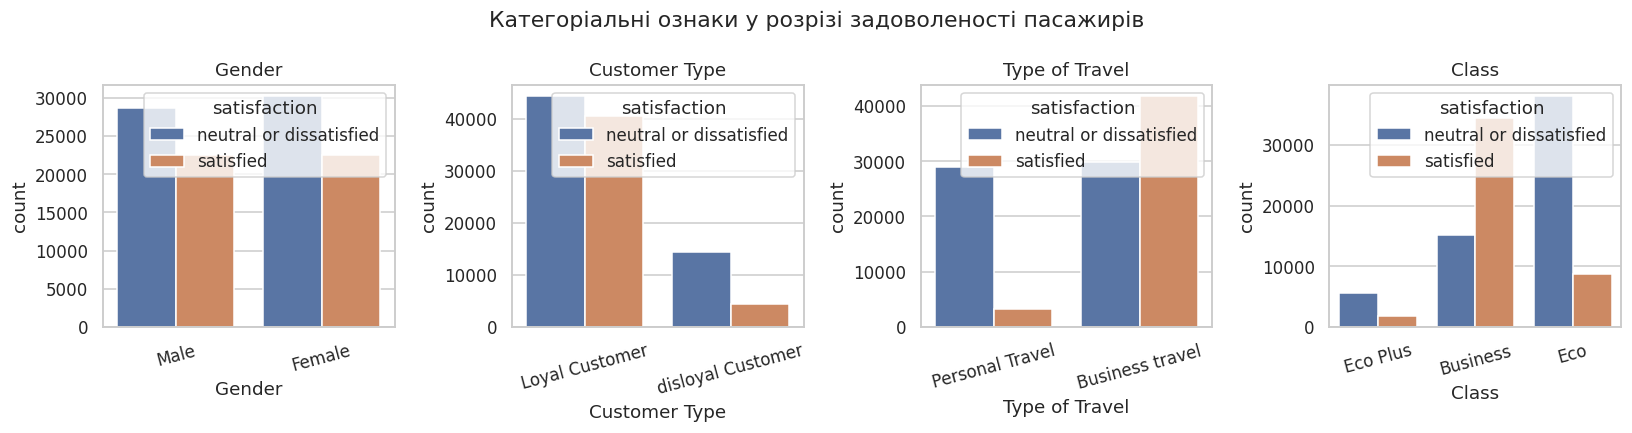

In [8]:
# Чотири категоріальні ознаки
cat_features = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Чотири графіки в один рядок
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
# Для кожної ознаки рахуємо пасажирів у кожній категорії з розбивкою за задоволеністю
for ax, col in zip(axes, cat_features):
    # hue="satisfaction" - різні кольори для задоволених і незадоволених
    sns.countplot(data=df, x=col, hue="satisfaction", ax=ax)
    # Заголовок графіка
    ax.set_title(col)
    # Нахиляємо підписи категорій, щоб вони не накладались
    ax.tick_params(axis="x", rotation=15)
# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Категоріальні ознаки у розрізі задоволеності пасажирів")
fig.tight_layout()
plt.show()

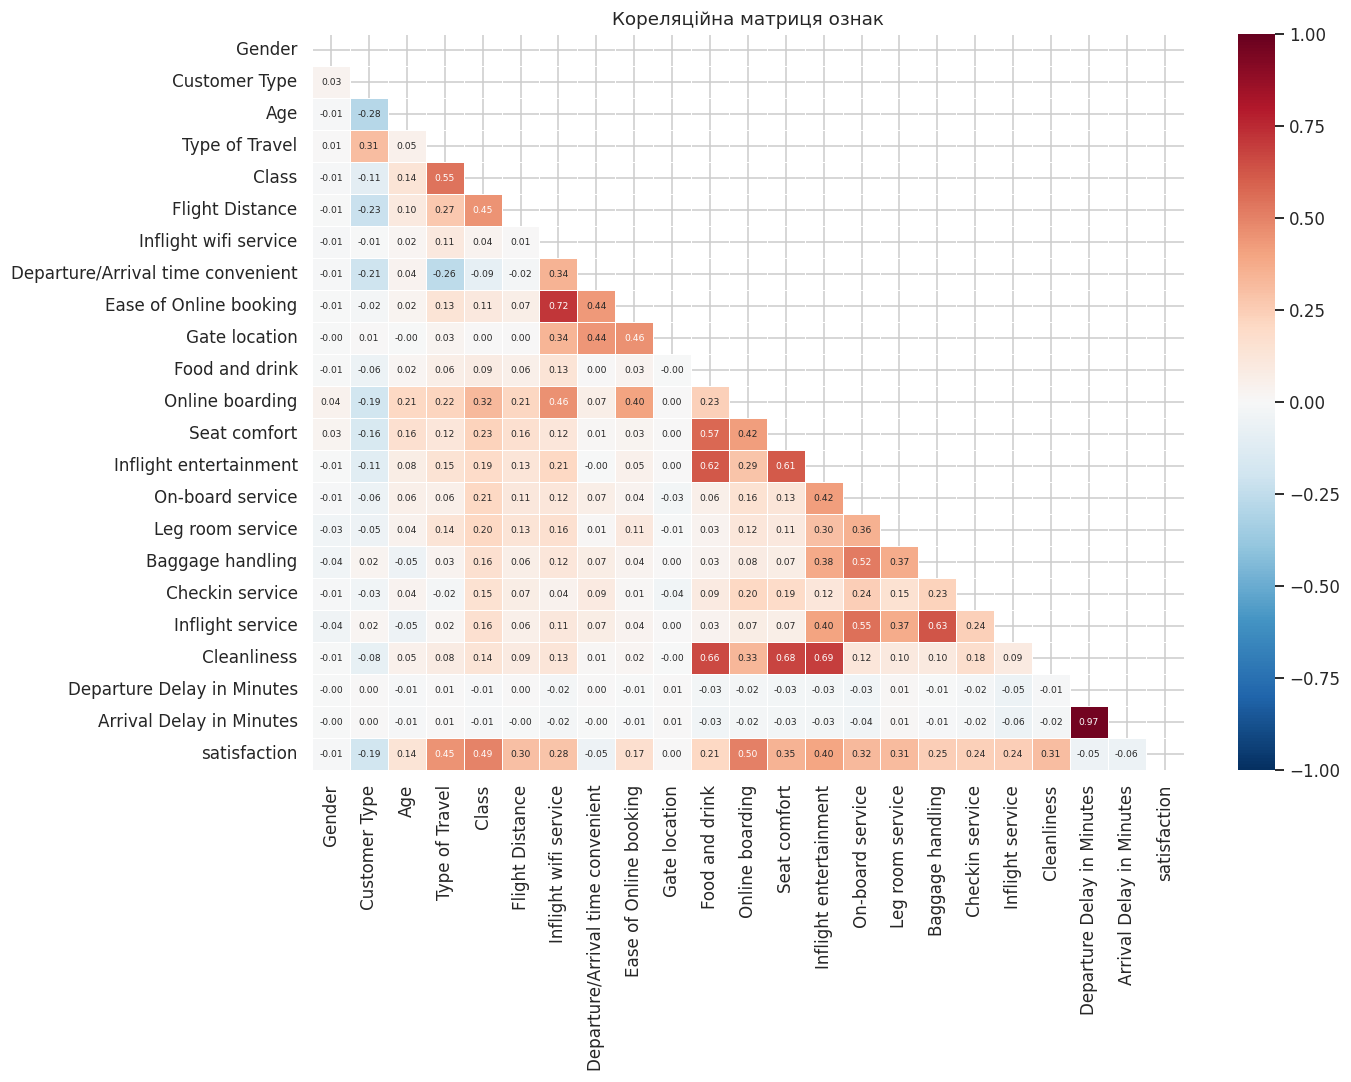

In [9]:
# Копія даних без службових колонок (номер рядка та id пасажира)
df_corr = df.drop(columns=["Unnamed: 0", "id"]).copy()
# Цільову змінну переводимо в число: satisfied = 1, інакше 0
df_corr["satisfaction"] = (df_corr["satisfaction"] == "satisfied").astype(int)
# Бінарні текстові ознаки переводимо в числа 0/1
for col in ["Gender", "Customer Type", "Type of Travel"]:
    df_corr[col] = pd.factorize(df_corr[col])[0]
# Клас обслуговування - за зростанням рівня: Eco < Eco Plus < Business
df_corr["Class"] = df_corr["Class"].map({"Eco": 0, "Eco Plus": 1, "Business": 2})

# Обчислюємо матрицю кореляцій Пірсона між усіма числовими колонками
corr = df_corr.corr(numeric_only=True)

# Фігура для теплової карти
fig, ax = plt.subplots(figsize=(13, 10))
# Маска ховає верхній трикутник матриці, бо він дублює нижній
mask = np.triu(np.ones_like(corr, dtype=bool))
# Теплова карта: червоний - додатна кореляція, синій - від'ємна, числа в клітинках
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6}, linewidths=0.4, ax=ax)
# Заголовок, вирівнювання та відображення
ax.set_title("Кореляційна матриця ознак")
fig.tight_layout()
plt.show()

--- Кореляція ознак із satisfaction ---
Online boarding                      0.504
Class                                0.494
Type of Travel                       0.449
Inflight entertainment               0.398
Seat comfort                         0.349
On-board service                     0.322
Leg room service                     0.313
Cleanliness                          0.305
Flight Distance                      0.299
Inflight wifi service                0.284
Baggage handling                     0.248
Inflight service                     0.245
Checkin service                      0.236
Food and drink                       0.210
Ease of Online booking               0.172
Age                                  0.137
Gate location                        0.001
Gender                              -0.012
Departure Delay in Minutes          -0.050
Departure/Arrival time convenient   -0.052
Arrival Delay in Minutes            -0.058
Customer Type                       -0.188


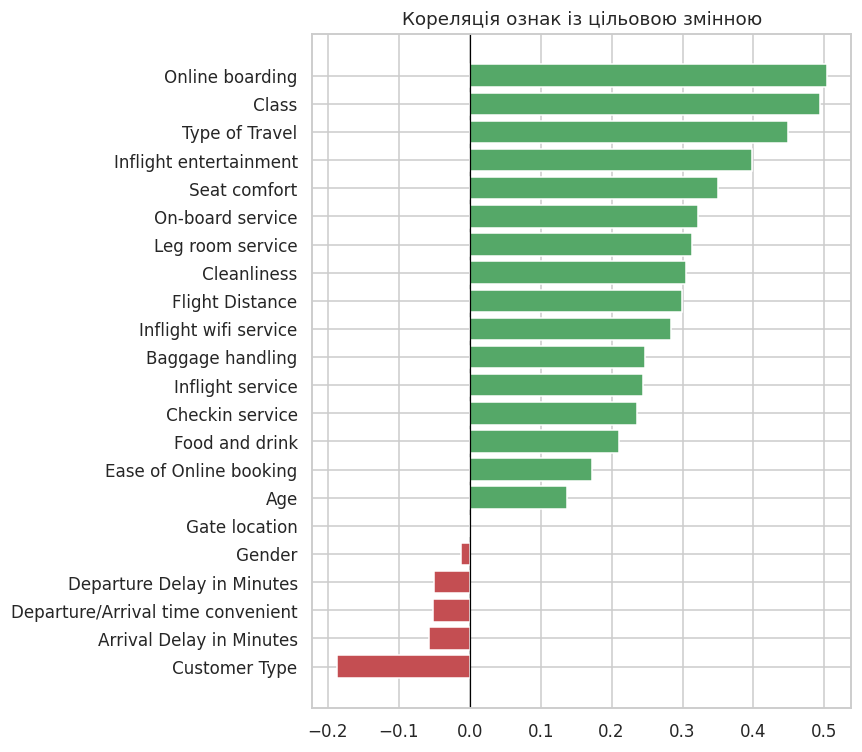


--- Пари сильно корельованих ознак (|r| > 0.5) ---
  Departure Delay in Minutes  <->  Arrival Delay in Minutes:  r = 0.965
  Inflight wifi service  <->  Ease of Online booking:  r = 0.716
  Inflight entertainment  <->  Cleanliness:  r = 0.692
  Seat comfort  <->  Cleanliness:  r = 0.679
  Food and drink  <->  Cleanliness:  r = 0.658
  Baggage handling  <->  Inflight service:  r = 0.629
  Food and drink  <->  Inflight entertainment:  r = 0.623
  Seat comfort  <->  Inflight entertainment:  r = 0.611
  Food and drink  <->  Seat comfort:  r = 0.575
  On-board service  <->  Inflight service:  r = 0.551
  Type of Travel  <->  Class:  r = 0.545
  On-board service  <->  Baggage handling:  r = 0.519
  Online boarding  <->  satisfaction:  r = 0.504


In [10]:
# Кореляція кожної ознаки з satisfaction, від найсильнішої додатної до від'ємної
target_corr = corr["satisfaction"].drop("satisfaction").sort_values(ascending=False)
# Виводимо значення, округлені до 3 знаків
print("--- Кореляція ознак із satisfaction ---")
print(target_corr.round(3).to_string())

# Горизонтальна стовпчикова діаграма кореляцій
fig, ax = plt.subplots(figsize=(8, 7))
# Зелений - додатний зв'язок, червоний - від'ємний
colors = ["#55A868" if v > 0 else "#C44E52" for v in target_corr.values]
# Малюємо стовпці
ax.barh(target_corr.index, target_corr.values, color=colors)
# Найсильніший зв'язок показуємо зверху
ax.invert_yaxis()
# Вертикальна лінія на нулі для орієнтира
ax.axvline(0, color="black", linewidth=0.8)
# Заголовок, вирівнювання та відображення
ax.set_title("Кореляція ознак із цільовою змінною")
fig.tight_layout()
plt.show()

# Шукаємо пари ознак із сильною взаємною кореляцією (|r| > 0.5) - мультиколінеарність
print("\n--- Пари сильно корельованих ознак (|r| > 0.5) ---")
# Беремо верхній трикутник матриці без діагоналі і перетворюємо на список пар
pairs = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack()
# Залишаємо пари з |r| > 0.5 і сортуємо за спаданням
strong = pairs[pairs.abs() > 0.5].sort_values(ascending=False)
# Виводимо кожну пару та її коефіцієнт кореляції
for (a, b), v in strong.items():
    print(f"  {a}  <->  {b}:  r = {v:.3f}")

--- Розподіл цільового класу ---
  neutral or dissatisfied   :  58879  (56.67%)
  satisfied                 :  45025  (43.33%)

Коефіцієнт дисбалансу (majority/minority): 1.308 : 1


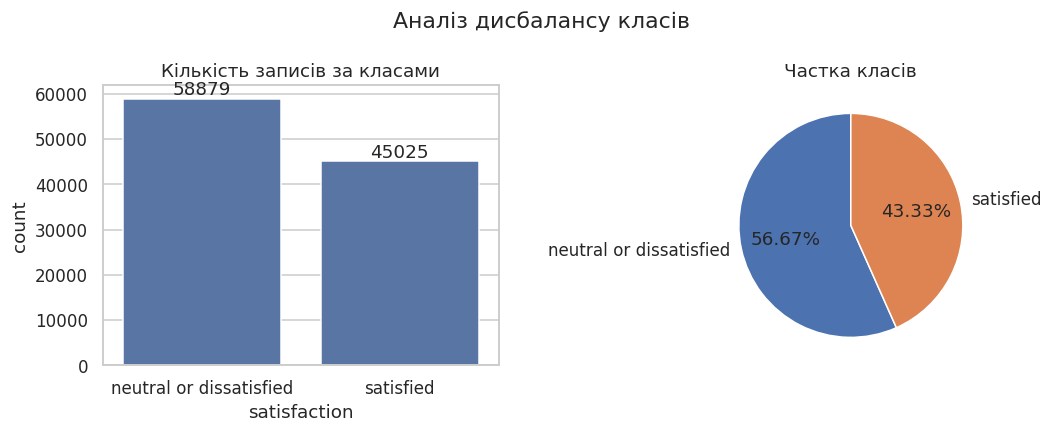

In [11]:
# Кількість записів кожного класу
counts = df["satisfaction"].value_counts()
# Частка кожного класу (від 0 до 1)
shares = df["satisfaction"].value_counts(normalize=True)

# Виводимо кількість і частку кожного класу
print("--- Розподіл цільового класу ---")
for cls in counts.index:
    print(f"  {cls:<26}: {counts[cls]:>6}  ({shares[cls] * 100:.2f}%)")

# Коефіцієнт дисбалансу: у скільки разів більший клас переважає менший
imbalance_ratio = counts.max() / counts.min()
print(f"\nКоефіцієнт дисбалансу (majority/minority): {imbalance_ratio:.3f} : 1")

# Два графіки поруч
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Лівий: кількість записів кожного класу
sns.countplot(data=df, x="satisfaction", ax=axes[0])
# Підписуємо кількість над стовпцями
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d")
axes[0].set_title("Кількість записів за класами")

# Правий: кругова діаграма часток класів
axes[1].pie(counts.values, labels=counts.index, autopct="%1.2f%%", startangle=90)
axes[1].set_title("Частка класів")

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Аналіз дисбалансу класів")
fig.tight_layout()
plt.show()

In [12]:
# Створюємо робочу копію датасету, щоб не змінювати оригінальний df
data = df.copy()
# Виводимо початковий розмір таблиці (рядки, колонки)
print("Початковий розмір:", data.shape)

# Видаляємо службові колонки: 'Unnamed: 0' - старий індекс, 'id' - номер пасажира;
# вони не несуть корисної інформації для навчання моделі
data = data.drop(columns=["Unnamed: 0", "id"])
# Перевіряємо розмір після видалення (має стати на 2 колонки менше)
print("Після видалення 'Unnamed: 0' та 'id':", data.shape)

# Рахуємо кількість пропущених значень у колонці затримки прибуття
n_missing = data["Arrival Delay in Minutes"].isna().sum()
# Заповнюємо пропуски значенням затримки вильоту того ж рейсу:
# за кореляційним аналізом ці ознаки майже тотожні (r = 0.965)
data["Arrival Delay in Minutes"] = data["Arrival Delay in Minutes"].fillna(
    data["Departure Delay in Minutes"])
# Виводимо, скільки пропусків заповнено і скільки залишилось у всьому датасеті
print(f"Заповнено пропусків: {n_missing}, залишилось: {data.isna().sum().sum()}")

# Перевіряємо наявність повністю однакових рядків (дублікатів)
print("Кількість дублікатів:", data.duplicated().sum())

Початковий розмір: (103904, 25)
Після видалення 'Unnamed: 0' та 'id': (103904, 23)
Заповнено пропусків: 310, залишилось: 0
Кількість дублікатів: 0


In [13]:
# Словник відповідностей для бінарних категоріальних ознак (дві категорії -> 0/1)
binary_map = {
    # Стать пасажира: чоловік = 0, жінка = 1
    "Gender":         {"Male": 0, "Female": 1},
    # Тип клієнта: нелояльний = 0, лояльний = 1
    "Customer Type":  {"disloyal Customer": 0, "Loyal Customer": 1},
    # Мета подорожі: особиста = 0, ділова = 1
    "Type of Travel": {"Personal Travel": 0, "Business travel": 1},
}
# Проходимо по кожній бінарній ознаці та її словнику відповідностей
for col, mapping in binary_map.items():
    # Замінюємо текстові значення на числові згідно зі словником
    data[col] = data[col].map(mapping)

# Class має 3 категорії (Eco, Eco Plus, Business), тому кодуємо через one-hot:
# створюються 3 окремі колонки 0/1. Порядкове кодування (0, 1, 2) задало б
# нейромережі штучну "відстань" між класами обслуговування
data = pd.get_dummies(data, columns=["Class"], prefix="Class", dtype=int)

# Кодуємо цільову змінну: satisfied = 1, neutral or dissatisfied = 0
data["satisfaction"] = (data["satisfaction"] == "satisfied").astype(int)

# Виводимо новий розмір таблиці (з'явились колонки one-hot)
print("Розмір після кодування:", data.shape)
# Перевіряємо, що всі колонки тепер числові (жодної типу object)
print("Типи даних:", data.dtypes.value_counts().to_dict())
# Показуємо перші 5 рядків закодованої таблиці
data.head()

Розмір після кодування: (103904, 25)
Типи даних: {dtype('int64'): 24, dtype('float64'): 1}


,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,13,0,460,3,4,3,1,5,...,4,4,5,5,25,18.0,0,0,0,1
1,0,0,25,1,235,3,2,3,3,1,...,3,1,4,1,1,6.0,0,1,0,0
2,1,1,26,1,1142,2,2,2,2,5,...,4,4,4,5,0,0.0,1,1,0,0
3,1,1,25,1,562,2,5,5,5,2,...,3,1,4,2,11,9.0,0,1,0,0
4,0,1,61,1,214,3,3,3,3,4,...,4,3,3,3,0,0.0,1,1,0,0


                            Асиметрія до  Асиметрія після log1p
Flight Distance                     1.11                  -0.20
Departure Delay in Minutes          6.73                   0.92
Arrival Delay in Minutes            6.56                   0.87


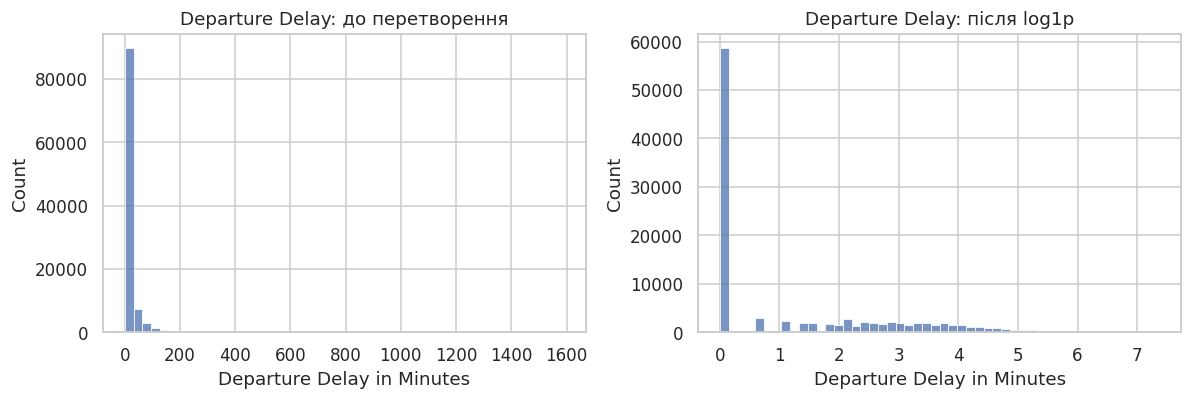

In [14]:
# Список ознак із сильною правосторонньою асиметрією (виявлено в EDA)
skewed = ["Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

# Обчислюємо коефіцієнт асиметрії (skewness) до перетворення
skew_before = data[skewed].skew()
# Застосовуємо log(1 + x): стискає довгий правий хвіст розподілу
# і коректно працює з нулями (log(1 + 0) = 0)
data[skewed] = np.log1p(data[skewed])
# Обчислюємо коефіцієнт асиметрії після перетворення
skew_after = data[skewed].skew()

# Виводимо таблицю порівняння асиметрії до і після, округлену до 2 знаків
print(pd.DataFrame({"Асиметрія до": skew_before.round(2),
                    "Асиметрія після log1p": skew_after.round(2)}))

# Створюємо фігуру з двома графіками поруч
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
# Лівий графік: розподіл затримки вильоту в оригінальних даних (df не змінювався)
sns.histplot(df["Departure Delay in Minutes"], bins=50, ax=axes[0])
# Підпис лівого графіка
axes[0].set_title("Departure Delay: до перетворення")
# Правий графік: розподіл тієї ж ознаки після логарифмування
sns.histplot(data["Departure Delay in Minutes"], bins=50, ax=axes[1])
# Підпис правого графіка
axes[1].set_title("Departure Delay: після log1p")
# Автоматично вирівнюємо відступи між графіками
fig.tight_layout()
# Відображаємо графіки
plt.show()

In [15]:
# Матриця ознак X: усі колонки, крім цільової змінної
X = data.drop(columns=["satisfaction"])
# Вектор міток y: значення цільової змінної у вигляді масиву numpy
y = data["satisfaction"].values
# Зберігаємо список назв ознак (знадобиться для аналізу та графіків)
FEATURE_NAMES = list(X.columns)

# Виводимо розмірності X та y
print("X:", X.shape, " y:", y.shape)
# Виводимо перелік усіх ознак, що подаватимуться на вхід моделі
print("Ознаки:", FEATURE_NAMES)

X: (103904, 24)  y: (103904,)
Ознаки: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


PC1 пояснює 17.99%, PC2 - 10.02% дисперсії
Для 90% дисперсії потрібно 15 компонент із 24
Для 95% дисперсії потрібно 19 компонент із 24


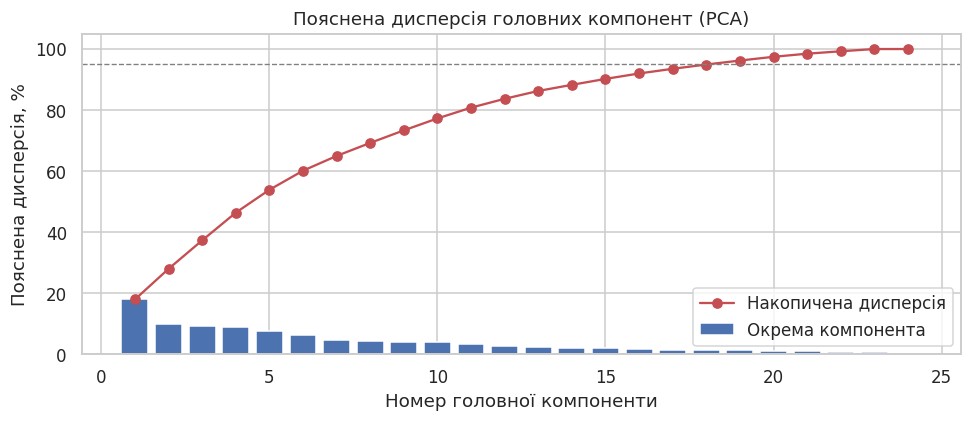

In [16]:
# Імпортуємо стандартизацію ознак і метод головних компонент
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA чутливий до масштабу ознак, тому спершу приводимо їх до mean = 0, std = 1.
# Тут PCA використовується лише для аналізу розмірності, тому scaler навчаємо на всіх
# даних; для моделей масштабування буде виконано окремо, лише на train (п. 5)
X_std = StandardScaler().fit_transform(X)

# Навчаємо PCA з усіма компонентами (їх стільки ж, скільки ознак)
pca = PCA(random_state=42).fit(X_std)
# Частка дисперсії, яку пояснює кожна компонента окремо
explained = pca.explained_variance_ratio_
# Накопичена (кумулятивна) частка поясненої дисперсії
cumulative = np.cumsum(explained)

# Мінімальна кількість компонент, що пояснюють 90% дисперсії
n90 = np.argmax(cumulative >= 0.90) + 1
# Мінімальна кількість компонент, що пояснюють 95% дисперсії
n95 = np.argmax(cumulative >= 0.95) + 1
# Виводимо внесок перших двох компонент
print(f"PC1 пояснює {explained[0]*100:.2f}%, PC2 - {explained[1]*100:.2f}% дисперсії")
# Виводимо, скільки компонент потрібно для 90% і 95% дисперсії
print(f"Для 90% дисперсії потрібно {n90} компонент із {X.shape[1]}")
print(f"Для 95% дисперсії потрібно {n95} компонент із {X.shape[1]}")

# Створюємо фігуру для scree-діаграми
fig, ax = plt.subplots(figsize=(9, 4))
# Стовпчики: дисперсія, яку пояснює кожна компонента, у відсотках
ax.bar(range(1, len(explained) + 1), explained * 100, label="Окрема компонента")
# Лінія: накопичена пояснена дисперсія у відсотках
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#C44E52",
        label="Накопичена дисперсія")
# Горизонтальна пунктирна лінія на рівні 95%
ax.axhline(95, ls="--", color="gray", linewidth=0.9)
# Підписи осей і заголовок графіка
ax.set_xlabel("Номер головної компоненти")
ax.set_ylabel("Пояснена дисперсія, %")
ax.set_title("Пояснена дисперсія головних компонент (PCA)")
# Легенда графіка
ax.legend()
# Вирівнюємо відступи та відображаємо графік
fig.tight_layout()
plt.show()

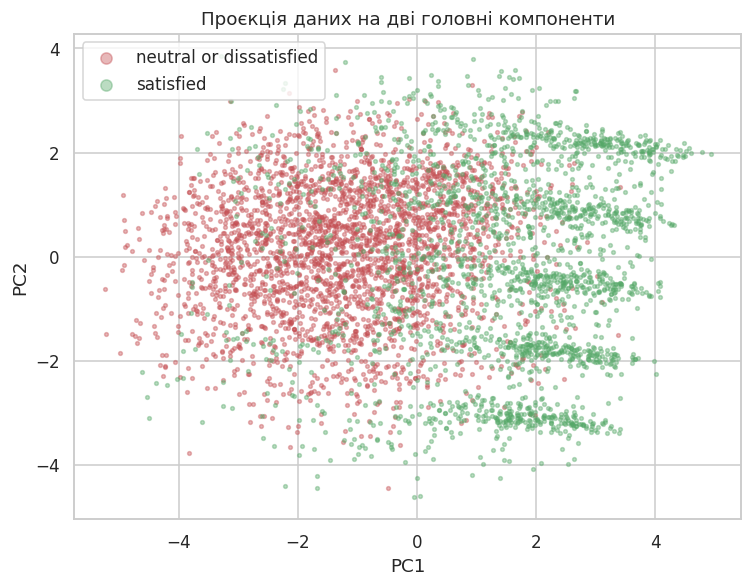

In [17]:
# Стискаємо дані до двох головних компонент для візуалізації на площині
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_std)
# Випадково обираємо 5000 точок, щоб графік не був перевантажений
idx = np.random.RandomState(42).choice(len(X_2d), 5000, replace=False)

# Створюємо фігуру для діаграми розсіювання
fig, ax = plt.subplots(figsize=(7, 5.5))
# Для кожного класу задаємо колір і підпис: червоний - незадоволені, зелений - задоволені
for cls, color, label in [(0, "#C44E52", "neutral or dissatisfied"),
                          (1, "#55A868", "satisfied")]:
    # Маска: які з обраних точок належать поточному класу
    m = y[idx] == cls
    # Малюємо точки класу в координатах PC1 та PC2
    ax.scatter(X_2d[idx][m, 0], X_2d[idx][m, 1], s=6, alpha=0.4, c=color, label=label)
# Підписи осей і заголовок графіка
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Проєкція даних на дві головні компоненти")
# Легенда зі збільшеними маркерами для кращої видимості
ax.legend(markerscale=3)
# Вирівнюємо відступи та відображаємо графік
fig.tight_layout()
plt.show()

In [18]:
# Імпортуємо функцію для розбиття даних на вибірки
from sklearn.model_selection import train_test_split

# Фіксоване зерно генератора, щоб поділ був однаковим при кожному запуску (як у лабі 1)
SEED = 42

# Крок 1: відокремлюємо тестову вибірку (15% усіх даних);
# stratify=y зберігає однакову пропорцію класів в обох частинах
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)

# Крок 2: з решти 85% відокремлюємо валідаційну вибірку;
# частка 0.15 / 0.85 від залишку дає рівно 15% від усіх даних
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=SEED, stratify=y_temp)

# Загальна кількість записів для обчислення відсотків
total = len(X)
# Для кожної вибірки виводимо кількість записів, її частку та частку класу satisfied
for name, Xs, ys in [("Train", X_train, y_train),
                     ("Validation", X_val, y_val),
                     ("Test", X_test, y_test)]:
    print(f"{name:<11}: {len(Xs):>6} записів ({len(Xs) / total * 100:.2f}%), "
          f"частка satisfied: {ys.mean() * 100:.2f}%")

Train      :  72732 записів (70.00%), частка satisfied: 43.33%
Validation :  15586 записів (15.00%), частка satisfied: 43.33%
Test       :  15586 записів (15.00%), частка satisfied: 43.33%


            neutral or dissatisfied  satisfied
Вибірка                                       
Train                         41215      31517
Validation                     8832       6754
Test                           8832       6754


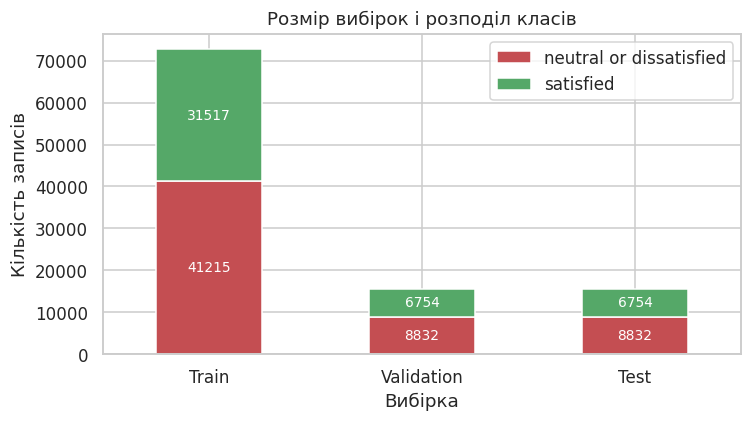

In [19]:
# Таблиця: кількість записів кожного класу в кожній вибірці
split_df = pd.DataFrame({
    # Назви вибірок
    "Вибірка": ["Train", "Validation", "Test"],
    # Кількість незадоволених пасажирів (клас 0) у кожній вибірці
    "neutral or dissatisfied": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    # Кількість задоволених пасажирів (клас 1) у кожній вибірці
    "satisfied": [(y_train == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
}).set_index("Вибірка")
# Виводимо таблицю
print(split_df)

# Складена стовпчикова діаграма: висота стовпця - розмір вибірки, кольори - класи
ax = split_df.plot(kind="bar", stacked=True, figsize=(7, 4),
                   color=["#C44E52", "#55A868"], rot=0)
# Підписуємо кількість записів усередині кожного сегмента стовпця
for c in ax.containers:
    ax.bar_label(c, label_type="center", fmt="%d", color="white", fontsize=9)
# Підпис осі Y і заголовок графіка
ax.set_ylabel("Кількість записів")
ax.set_title("Розмір вибірок і розподіл класів")
# Вирівнюємо відступи та відображаємо графік
plt.tight_layout()
plt.show()

In [20]:
# Імпортуємо стандартизацію ознак
from sklearn.preprocessing import StandardScaler

# Створюємо об'єкт стандартизації: кожна ознака приводиться до mean = 0 і std = 1
scaler = StandardScaler()
# Навчаємо scaler ТІЛЬКИ на train (обчислюємо середнє і std) та одразу трансформуємо train
X_train_sc = scaler.fit_transform(X_train)
# Val і test трансформуємо з параметрами, обчисленими на train, щоб уникнути витоку даних
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# Перевірка: у train середнє = 0 і std = 1, у val і test - дуже близько до цього
print("Train: mean =", X_train_sc.mean().round(3), " std =", X_train_sc.std().round(3))
print("Val  : mean =", X_val_sc.mean().round(3), " std =", X_val_sc.std().round(3))
print("Test : mean =", X_test_sc.mean().round(3), " std =", X_test_sc.std().round(3))

Train: mean = 0.0  std = 1.0
Val  : mean = -0.003  std = 1.0
Test : mean = -0.002  std = 0.999


До SMOTE   : [41215 31517] (усього 72732)
Після SMOTE: [41215 41215] (усього 82430)
Додано синтетичних записів: 9698


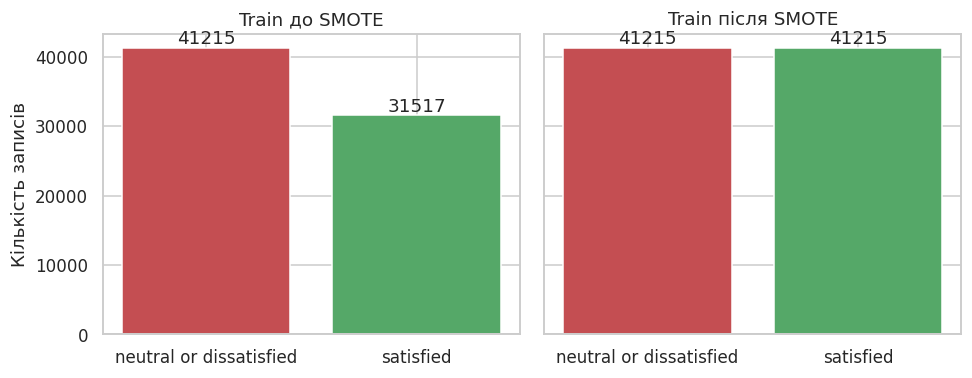

In [21]:
# Імпортуємо SMOTE з бібліотеки imbalanced-learn
# (якщо бібліотеки немає, виконай в окремій клітинці: !pip install imbalanced-learn)
from imblearn.over_sampling import SMOTE

# Створюємо об'єкт SMOTE: нові приклади класу-меншості генеруються
# на відрізках між записом і його 5 найближчими сусідами того ж класу
smote = SMOTE(random_state=SEED, k_neighbors=5)
# Балансуємо ТІЛЬКИ навчальну вибірку; val і test лишаються з реальним розподілом класів
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

# Кількість записів кожного класу [клас 0, клас 1] до та після балансування
print("До SMOTE   :", np.bincount(y_train), f"(усього {len(y_train)})")
print("Після SMOTE:", np.bincount(y_train_bal), f"(усього {len(y_train_bal)})")
# Скільки синтетичних записів додано
print("Додано синтетичних записів:", len(y_train_bal) - len(y_train))

# Два графіки поруч зі спільною віссю Y для порівняння
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
# Малюємо розподіл класів до і після SMOTE
for ax, labels, title in [(axes[0], y_train, "Train до SMOTE"),
                          (axes[1], y_train_bal, "Train після SMOTE")]:
    # Рахуємо кількість записів кожного класу
    counts = np.bincount(labels)
    # Стовпчики: червоний - незадоволені, зелений - задоволені
    bars = ax.bar(["neutral or dissatisfied", "satisfied"], counts,
                  color=["#C44E52", "#55A868"])
    # Підписуємо кількість над кожним стовпчиком
    ax.bar_label(bars, fmt="%d")
    # Заголовок графіка
    ax.set_title(title)
# Підпис осі Y для лівого графіка
axes[0].set_ylabel("Кількість записів")
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

In [22]:
# Імпортуємо PyTorch
import torch
# TensorDataset об'єднує ознаки й мітки в набір даних, DataLoader ділить його на батчі
from torch.utils.data import TensorDataset, DataLoader

# Фіксуємо зерно генератора PyTorch для відтворюваності результатів
torch.manual_seed(SEED)
# Навчаємо на CPU, як і в лабі 1, щоб час навчання TensorFlow і PyTorch був порівнянний
device = torch.device("cpu")
# Виводимо версію PyTorch і пристрій
print("PyTorch:", torch.__version__, "| пристрій:", device)

# PyTorch працює з тензорами, тому перетворюємо масиви NumPy у тензори типу float32.
# unsqueeze(1) перетворює мітки з форми (N,) у (N, 1) - так само, як вихід мережі
X_train_t = torch.tensor(X_train_bal, dtype=torch.float32)
y_train_t = torch.tensor(y_train_bal, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_sc, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_sc, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Розмір батча - такий самий, як у лабі 1
BATCH_SIZE = 256
# Об'єднуємо ознаки і мітки навчальної вибірки в один набір даних
train_dataset = TensorDataset(X_train_t, y_train_t)
# DataLoader на кожній епосі перемішує train і видає його батчами по 256 записів;
# генератор із фіксованим зерном робить перемішування відтворюваним
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))

# Перевіряємо розміри тензорів кожної вибірки
for name, Xt, yt in [("Train", X_train_t, y_train_t),
                     ("Validation", X_val_t, y_val_t),
                     ("Test", X_test_t, y_test_t)]:
    print(f"{name:<11}: X {tuple(Xt.shape)}, y {tuple(yt.shape)}, тип {Xt.dtype}")
# Кількість батчів за одну епоху
print("Батчів за епоху:", len(train_loader))
# Беремо один батч, щоб переконатися, що DataLoader працює правильно
xb, yb = next(iter(train_loader))
print("Один батч: X", tuple(xb.shape), " y", tuple(yb.shape))

PyTorch: 2.11.0+cpu | пристрій: cpu
Train      : X (82430, 24), y (82430, 1), тип torch.float32
Validation : X (15586, 24), y (15586, 1), тип torch.float32
Test       : X (15586, 24), y (15586, 1), тип torch.float32
Батчів за епоху: 322
Один батч: X (256, 24)  y (256, 1)


In [23]:
# Модуль nn містить шари нейронних мереж PyTorch (Linear, BatchNorm1d, Dropout тощо)
import torch.nn as nn

# Кількість вхідних ознак мережі (кількість колонок навчального тензора)
INPUT_DIM = X_train_t.shape[1]
print("Кількість вхідних ознак:", INPUT_DIM)


# Функція повертає шар активації за назвою, щоб легко перемикати активації в експериментах
def make_activation(name):
    # ReLU: f(z) = max(0, z)
    if name == "relu":
        return nn.ReLU()
    # LeakyReLU: для від'ємних z залишає нахил 0.1 (як у лабі 1)
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.1)
    # GELU: гладка активація, точна формула (як у Keras)
    if name == "gelu":
        return nn.GELU()
    # Якщо передано невідому назву, зупиняємо виконання з помилкою
    raise ValueError(f"Невідома функція активації: {name}")


# Функція ініціалізації ваг: у PyTorch за замовчуванням інший спосіб, ніж у Keras,
# тому задаємо такий самий, як у Keras, щоб порівняння фреймворків було чесним
def init_weights(module):
    # Ініціалізуємо лише повнозв'язні шари
    if isinstance(module, nn.Linear):
        # Ваги - за методом Xavier (Glorot uniform), як у Keras за замовчуванням
        nn.init.xavier_uniform_(module.weight)
        # Зсуви (bias) - нулі, як у Keras
        nn.init.zeros_(module.bias)

Кількість вхідних ознак: 24


In [24]:
# У PyTorch модель - це клас, успадкований від nn.Module
class BaseNet(nn.Module):
    # Конструктор: тут описуємо шари мережі
    def __init__(self, activation="relu"):
        # Викликаємо конструктор батьківського класу nn.Module (обов'язково)
        super().__init__()
        # nn.Sequential виконує шари послідовно, один за одним
        self.net = nn.Sequential(
            # 1-й прихований шар: 24 входи -> 256 нейронів + активація
            nn.Linear(INPUT_DIM, 256), make_activation(activation),
            # 2-й прихований шар: 256 -> 128 нейронів + активація
            nn.Linear(256, 128), make_activation(activation),
            # 3-й прихований шар: 128 -> 64 нейрони + активація
            nn.Linear(128, 64), make_activation(activation),
            # Вихідний шар: 1 нейрон, сигмоїда повертає ймовірність класу satisfied (0..1)
            nn.Linear(64, 1), nn.Sigmoid(),
        )
        # Застосовуємо ініціалізацію ваг до всіх шарів
        self.apply(init_weights)

    # Прямий прохід: як дані проходять через мережу
    def forward(self, x):
        return self.net(x)


# Фіксуємо зерно, щоб початкові ваги були відтворюваними
torch.manual_seed(SEED)
# Створюємо демонстраційну модель з ReLU
base_demo = BaseNet("relu")
# Виводимо структуру мережі
print(base_demo)
# Рахуємо кількість параметрів (ваги + зсуви всіх шарів)
print("Параметрів:", sum(p.numel() for p in base_demo.parameters()))
# Перевіряємо прохід одного батча: на виході має бути (256, 1) - одна ймовірність на пасажира
print("Вихід на одному батчі:", tuple(base_demo(xb).shape))

BaseNet(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Параметрів: 47617
Вихід на одному батчі: (256, 1)


In [25]:
# Коефіцієнт L2-регуляризації (як у лабі 1)
L2_LAMBDA = 1e-4
# Частка нейронів, які Dropout вимикає в кожному прихованому шарі (як у лабі 1)
DROPOUT_RATES = [0.3, 0.3, 0.2]


# Ускладнена мережа: ті самі 3 шари, доповнені регуляризацією
class OptimizedNet(nn.Module):
    # Конструктор: описуємо шари
    def __init__(self, activation="relu"):
        # Обов'язковий виклик конструктора nn.Module
        super().__init__()
        # Список, у який додаємо шари прихованої частини
        layers = []
        # Кількість входів першого шару
        in_features = INPUT_DIM
        # Для кожного прихованого шару: кількість нейронів і частка Dropout
        for units, rate in zip([256, 128, 64], DROPOUT_RATES):
            layers += [
                # Повнозв'язний шар
                nn.Linear(in_features, units),
                # Batch Normalization; momentum і eps задано як у Keras
                nn.BatchNorm1d(units, momentum=0.01, eps=1e-3),
                # Функція активації
                make_activation(activation),
                # Dropout: вимикає частку нейронів лише під час навчання
                nn.Dropout(rate),
            ]
            # Виходи цього шару стають входами наступного
            in_features = units
        # Об'єднуємо приховані шари в послідовний блок
        self.hidden = nn.Sequential(*layers)
        # Вихідний шар: 1 нейрон + сигмоїда
        self.output = nn.Sequential(nn.Linear(in_features, 1), nn.Sigmoid())
        # Ініціалізуємо ваги як у Keras
        self.apply(init_weights)

    # Прямий прохід: спершу приховані шари, потім вихідний
    def forward(self, x):
        return self.output(self.hidden(x))

    # L2-штраф: λ * сума квадратів ваг прихованих шарів (як kernel_regularizer у Keras);
    # під час навчання цей штраф додаватиметься до функції втрат
    def l2_penalty(self):
        return L2_LAMBDA * sum((m.weight ** 2).sum()
                               for m in self.hidden if isinstance(m, nn.Linear))


# Фіксуємо зерно і створюємо демонстраційну модель з ReLU
torch.manual_seed(SEED)
opt_demo = OptimizedNet("relu")
# Виводимо структуру мережі
print(opt_demo)
# Параметри, що навчаються (ваги, зсуви, γ і β у BatchNorm)
trainable = sum(p.numel() for p in opt_demo.parameters())
# Ковзні середні та дисперсії BatchNorm - не навчаються, зберігаються окремо
buffers = sum(b.numel() for n, b in opt_demo.named_buffers() if "running" in n)
print("Навчальних параметрів:", trainable, "| статистик BN:", buffers,
      "| разом:", trainable + buffers)
# Значення L2-штрафу для початкових ваг
print("L2-штраф на старті:", round(opt_demo.l2_penalty().item(), 4))
# Перевіряємо прохід одного батча
print("Вихід на одному батчі:", tuple(opt_demo(xb).shape))

OptimizedNet(
  (hidden): Sequential(
    (0): Linear(in_features=24, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
  )
  (output): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Навчальних параметрів: 48513 | статистик BN: 896 | разом: 49409
L2-штраф на старті: 0.03
Вихід на одному батчі: (256, 1)


In [26]:
# Зводимо ключові характеристики обох архітектур в одну таблицю
comparison = pd.DataFrame({
    # Характеристики базової мережі
    "Базова": ["256 - 128 - 64", "ні", "ні", "ні",
               sum(p.numel() for p in base_demo.parameters())],
    # Характеристики ускладненої мережі
    "Ускладнена": ["256 - 128 - 64", "так, після кожного Linear", "0.3 / 0.3 / 0.2",
                   f"так, λ = {L2_LAMBDA}", trainable + buffers],
# Назви рядків таблиці
}, index=["Приховані шари (нейрони)", "Batch Normalization", "Dropout",
          "L2-регуляризація", "Кількість параметрів"])
# Виводимо таблицю
print(comparison.to_string())

                                  Базова                 Ускладнена
Приховані шари (нейрони)  256 - 128 - 64             256 - 128 - 64
Batch Normalization                   ні  так, після кожного Linear
Dropout                               ні            0.3 / 0.3 / 0.2
L2-регуляризація                      ні            так, λ = 0.0001
Кількість параметрів               47617                      49409


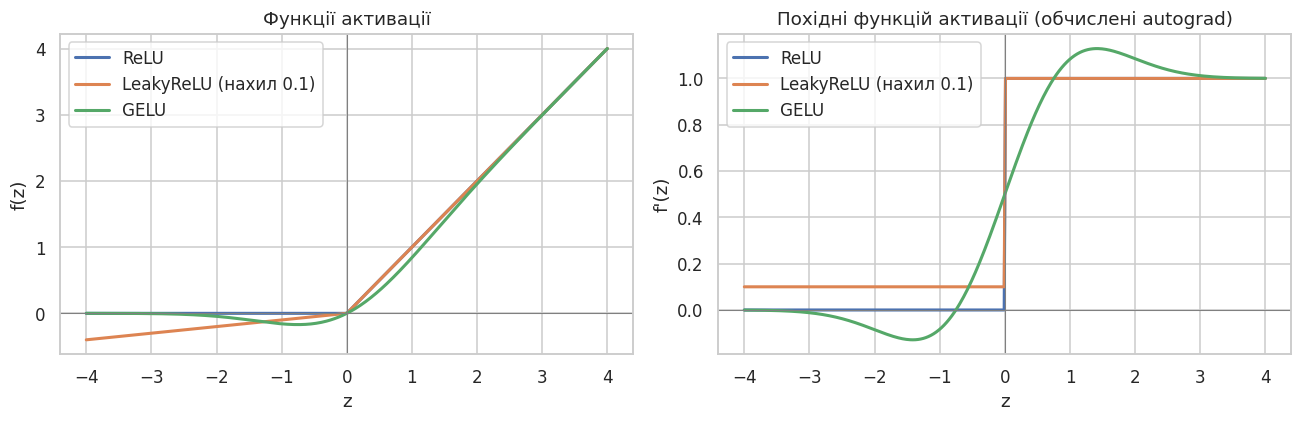

In [27]:
# Модуль функцій PyTorch: готові функції активації relu, leaky_relu, gelu
import torch.nn.functional as F

# 400 точок на відрізку [-4; 4]; requires_grad=True - PyTorch запам'ятовує операції,
# щоб потім автоматично обчислити похідні (механізм autograd)
z = torch.linspace(-4, 4, 400, requires_grad=True)

# Три функції активації, які порівнюємо (LeakyReLU з нахилом 0.1, як у мережі)
activations_fn = {
    "ReLU": F.relu,
    "LeakyReLU (нахил 0.1)": lambda t: F.leaky_relu(t, negative_slope=0.1),
    "GELU": F.gelu,
}

# Два графіки поруч: функції та їхні похідні
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, fn in activations_fn.items():
    # Значення функції активації в кожній точці
    out = fn(z)
    # Похідна, обчислена автоматично через autograd (саме так PyTorch рахує градієнти під час навчання)
    grad, = torch.autograd.grad(out.sum(), z)
    # Лівий графік: функція; detach() відокремлює тензор від графа обчислень для малювання
    axes[0].plot(z.detach(), out.detach(), linewidth=2, label=name)
    # Правий графік: похідна
    axes[1].plot(z.detach(), grad, linewidth=2, label=name)

# Оформлення лівого графіка
axes[0].set_title("Функції активації")
axes[0].set_xlabel("z")
axes[0].set_ylabel("f(z)")
# Оформлення правого графіка
axes[1].set_title("Похідні функцій активації (обчислені autograd)")
axes[1].set_xlabel("z")
axes[1].set_ylabel("f'(z)")
# Осі координат, легенда і сітка для обох графіків
for ax in axes:
    ax.axhline(0, color="gray", linewidth=0.7)
    ax.axvline(0, color="gray", linewidth=0.7)
    ax.legend()
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

In [28]:
# Модуль time потрібен для вимірювання часу навчання
import time

# Фіксовані гіперпараметри, однакові для всіх експериментів і такі самі, як у лабі 1
EPOCHS = 20            # кількість епох навчання
LEARNING_RATE = 1e-3   # швидкість навчання Adam (BATCH_SIZE = 256 задано в п. 5)

# Три функції активації, які порівнюємо
ACTIVATIONS = ["relu", "leaky_relu", "gelu"]
# Назви активацій для таблиць і графіків
ACT_LABELS = {"relu": "ReLU", "leaky_relu": "LeakyReLU", "gelu": "GELU"}
# Відповідність назви архітектури і класу моделі (з пункту 6)
BUILDERS = {"Базова": BaseNet, "Ускладнена": OptimizedNet}

# Функція втрат: бінарна крос-ентропія (аналог binary_crossentropy у Keras)
criterion = nn.BCELoss()


# Функція оцінює модель на вибірці: повертає втрати і точність
def evaluate(model, X_t, y_t):
    # Режим оцінки: Dropout вимкнено, BatchNorm використовує накопичені статистики
    model.eval()
    # Вимикаємо обчислення градієнтів - під час оцінки вони не потрібні
    with torch.no_grad():
        # Ймовірності класу satisfied
        proba = model(X_t)
        # Втрати на вибірці
        loss = criterion(proba, y_t)
        # Для ускладненої мережі додаємо L2-штраф (як у Keras, де він входить у loss)
        if hasattr(model, "l2_penalty"):
            loss = loss + model.l2_penalty()
        # Точність: частка прогнозів, що збіглися з правильними мітками
        acc = ((proba >= 0.5).float() == y_t).float().mean()
    # Повертаємо звичайні числа Python
    return loss.item(), acc.item()


# Один експеримент: створення моделі і ручний цикл навчання
def run_experiment(arch, activation):
    # Однакове зерно для кожного експерименту: однакові стартові ваги
    torch.manual_seed(SEED)
    # Створюємо модель потрібної архітектури і переносимо на пристрій (CPU)
    model = BUILDERS[arch](activation).to(device)
    # Оптимізатор Adam для всіх параметрів моделі
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # DataLoader із фіксованим зерном: однакове перемішування батчів для всіх моделей
    loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))
    # Історія метрик по епохах (як history у Keras)
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    # Фіксуємо час початку навчання
    start = time.time()

    # Цикл по епохах
    for epoch in range(EPOCHS):
        # Режим навчання: Dropout активний, BatchNorm оновлює статистики
        model.train()
        # Накопичувачі для середніх втрат і точності за епоху
        total_loss, correct, seen = 0.0, 0, 0
        # Цикл по батчах: xb - ознаки, yb - мітки
        for xb, yb in loader:
            # 1) Обнуляємо градієнти з попереднього кроку
            optimizer.zero_grad()
            # 2) Прямий прохід: мережа обчислює ймовірності
            proba = model(xb)
            # 3) Обчислюємо втрати
            loss = criterion(proba, yb)
            # Для ускладненої мережі додаємо L2-штраф за великі ваги
            if hasattr(model, "l2_penalty"):
                loss = loss + model.l2_penalty()
            # 4) Зворотне поширення: autograd обчислює градієнти всіх ваг
            loss.backward()
            # 5) Оновлюємо ваги за правилом Adam
            optimizer.step()
            # Накопичуємо суму втрат (зважену на розмір батча)
            total_loss += loss.item() * len(xb)
            # Накопичуємо кількість правильних прогнозів
            correct += ((proba >= 0.5).float() == yb).sum().item()
            # Накопичуємо кількість оброблених записів
            seen += len(xb)

        # Після епохи оцінюємо модель на валідаційній вибірці
        val_loss, val_acc = evaluate(model, X_val_t, y_val_t)
        # Зберігаємо метрики епохи в історію
        history["loss"].append(total_loss / seen)
        history["accuracy"].append(correct / seen)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        # Друкуємо короткий рядок із метриками (той самий формат, що в лабі 1)
        print(f"  Епоха {epoch + 1:02d}/{EPOCHS}   "
              f"loss: {history['loss'][-1]:.4f}   acc: {history['accuracy'][-1]:.4f}   |   "
              f"val_loss: {val_loss:.4f}   val_acc: {val_acc:.4f}")

    # Повертаємо модель, історію навчання і час у секундах
    return model, history, time.time() - start


# Виводимо план експерименту: 2 архітектури x 3 активації
print("План експерименту:")
for arch in BUILDERS:
    for act in ACTIVATIONS:
        print(f"  {arch} + {ACT_LABELS[act]}")
print(f"Разом конфігурацій: {len(BUILDERS) * len(ACTIVATIONS)}")
print(f"Фіксовані гіперпараметри: Adam, learning rate = {LEARNING_RATE}, "
      f"епох = {EPOCHS}, batch size = {BATCH_SIZE}")

План експерименту:
  Базова + ReLU
  Базова + LeakyReLU
  Базова + GELU
  Ускладнена + ReLU
  Ускладнена + LeakyReLU
  Ускладнена + GELU
Разом конфігурацій: 6
Фіксовані гіперпараметри: Adam, learning rate = 0.001, епох = 20, batch size = 256


In [29]:
# Словники для збереження результатів усіх експериментів
histories = {}        # історія втрат і точності по епохах
trained_models = {}   # навчені моделі
train_times = {}      # час навчання кожної моделі

# Перебираємо всі комбінації архітектури та функції активації
for arch in BUILDERS:
    for act in ACTIVATIONS:
        # Назва експерименту, наприклад "Базова + ReLU"
        key = f"{arch} + {ACT_LABELS[act]}"
        # Заголовок у лозі
        print(f"\n=== Експеримент: {key} ===")
        # Запускаємо навчання
        model, hist, seconds = run_experiment(arch, act)
        # Зберігаємо модель, історію навчання і час
        trained_models[key] = model
        histories[key] = hist
        train_times[key] = seconds
        # Виводимо час навчання цієї моделі
        print(f"  Час навчання: {seconds:.1f} с")

print("\nУсі 6 експериментів завершено.")


=== Експеримент: Базова + ReLU ===
  Епоха 01/20   loss: 0.2038   acc: 0.9161   |   val_loss: 0.1375   val_acc: 0.9443
  Епоха 02/20   loss: 0.1265   acc: 0.9472   |   val_loss: 0.1143   val_acc: 0.9520
  Епоха 03/20   loss: 0.1073   acc: 0.9538   |   val_loss: 0.1021   val_acc: 0.9562
  Епоха 04/20   loss: 0.0971   acc: 0.9572   |   val_loss: 0.0992   val_acc: 0.9575
  Епоха 05/20   loss: 0.0925   acc: 0.9585   |   val_loss: 0.0975   val_acc: 0.9544
  Епоха 06/20   loss: 0.0872   acc: 0.9615   |   val_loss: 0.0969   val_acc: 0.9561
  Епоха 07/20   loss: 0.0834   acc: 0.9630   |   val_loss: 0.0939   val_acc: 0.9596
  Епоха 08/20   loss: 0.0810   acc: 0.9640   |   val_loss: 0.0997   val_acc: 0.9548
  Епоха 09/20   loss: 0.0786   acc: 0.9644   |   val_loss: 0.0958   val_acc: 0.9603
  Епоха 10/20   loss: 0.0755   acc: 0.9657   |   val_loss: 0.0980   val_acc: 0.9576
  Епоха 11/20   loss: 0.0728   acc: 0.9670   |   val_loss: 0.0986   val_acc: 0.9581
  Епоха 12/20   loss: 0.0709   acc: 0.96

Архітектура Активація  Val accuracy, %  Val F1, %  Val ROC-AUC, %  Мін. val loss  Епоха мін. val loss  Val loss (епоха 20)  Час, с
     Базова      ReLU           95.765     95.050          99.330          0.094                    7                0.115  44.236
     Базова LeakyReLU           96.202     95.566          99.444          0.092                   11                0.098  47.936
     Базова      GELU           96.253     95.640          99.441          0.087                   11                0.114  52.646
 Ускладнена      ReLU           96.356     95.740          99.498          0.100                   17                0.101  78.738
 Ускладнена LeakyReLU           96.279     95.650          99.466          0.102                   18                0.104  75.831
 Ускладнена      GELU           96.381     95.756          99.501          0.100                   20                0.100  83.017

Val accuracy, %:
Архітектура  Базова  Ускладнена
Активація                      
R

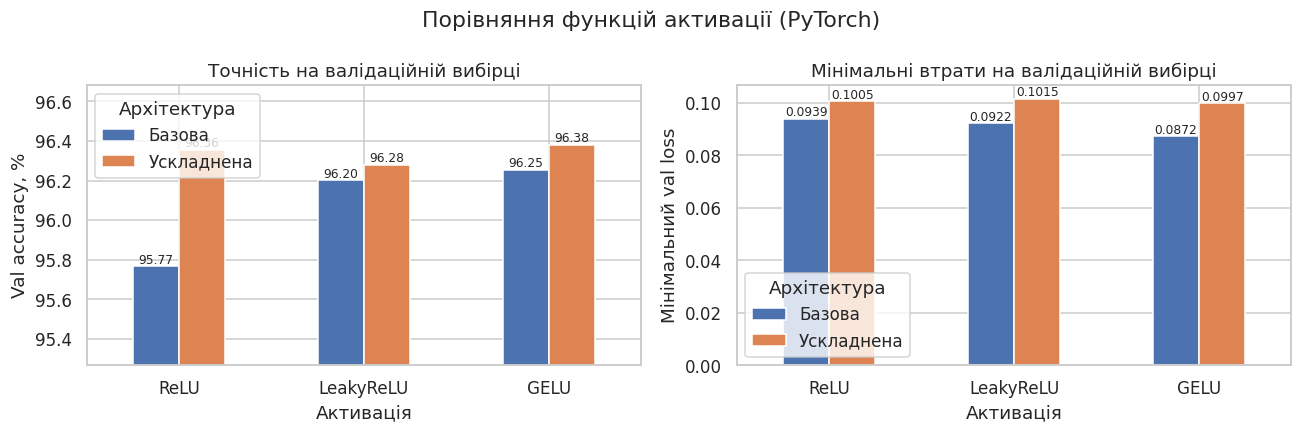

In [30]:
# Метрики якості з бібліотеки scikit-learn
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


# Функція повертає ймовірності класу satisfied у вигляді масиву NumPy
def predict_proba(model, X_t):
    # Режим оцінки: Dropout вимкнено
    model.eval()
    # Без обчислення градієнтів
    with torch.no_grad():
        # squeeze(1) прибирає зайвий вимір (N, 1) -> (N,), numpy() перетворює на масив
        return model(X_t).squeeze(1).numpy()


# Список рядків підсумкової таблиці
rows = []
# Оцінюємо кожну навчену модель на валідаційній вибірці
for key, model in trained_models.items():
    # Розбиваємо назву експерименту на архітектуру та активацію
    arch, act = key.split(" + ")
    # Ймовірності та прогнози класу за порогом 0.5
    proba = predict_proba(model, X_val_t)
    pred = (proba >= 0.5).astype(int)
    # Історія навчання цієї моделі
    h = histories[key]
    # Додаємо рядок із результатами
    rows.append({
        "Архітектура": arch,
        "Активація": act,
        "Val accuracy, %": accuracy_score(y_val, pred) * 100,      # частка правильних прогнозів
        "Val F1, %": f1_score(y_val, pred) * 100,                  # баланс precision і recall
        "Val ROC-AUC, %": roc_auc_score(y_val, proba) * 100,       # якість ранжування ймовірностей
        "Мін. val loss": min(h["val_loss"]),                       # найкращі втрати на validation
        "Епоха мін. val loss": int(np.argmin(h["val_loss"])) + 1,  # на якій епохі їх досягнуто
        f"Val loss (епоха {EPOCHS})": h["val_loss"][-1],           # втрати в кінці навчання
        "Час, с": train_times[key],                                # тривалість навчання
    })

# Формуємо таблицю результатів і виводимо її
act_results = pd.DataFrame(rows)
print(act_results.round(3).to_string(index=False))

# Зведена таблиця точності: рядки - активації, стовпці - архітектури
order = ["ReLU", "LeakyReLU", "GELU"]
pivot = act_results.pivot(index="Активація", columns="Архітектура",
                          values="Val accuracy, %").reindex(order)
print("\nVal accuracy, %:")
print(pivot.round(2).to_string())

# Два графіки поруч для порівняння активацій
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Лівий графік: точність на validation для кожної активації та архітектури
pivot.plot(kind="bar", ax=axes[0], rot=0, color=["#4C72B0", "#DD8452"])
# Звужуємо діапазон осі Y, щоб різницю між стовпцями було видно
axes[0].set_ylim(pivot.values.min() - 0.5, pivot.values.max() + 0.3)
axes[0].set_ylabel("Val accuracy, %")
axes[0].set_title("Точність на валідаційній вибірці")
# Підписуємо значення над стовпцями
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.2f", fontsize=8)

# Правий графік: мінімальні втрати на validation (менше - краще)
loss_pivot = act_results.pivot(index="Активація", columns="Архітектура",
                               values="Мін. val loss").reindex(order)
loss_pivot.plot(kind="bar", ax=axes[1], rot=0, color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Мінімальний val loss")
axes[1].set_title("Мінімальні втрати на валідаційній вибірці")
# Підписуємо значення над стовпцями
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.4f", fontsize=8)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Порівняння функцій активації (PyTorch)")
fig.tight_layout()
plt.show()

In [31]:
# Створюємо такий самий оптимізатор, як у run_experiment, щоб показати його налаштування
opt_check = torch.optim.Adam(BaseNet("relu").parameters(), lr=LEARNING_RATE)
# Словник налаштувань оптимізатора: lr, betas, eps, weight_decay
cfg = opt_check.defaults
# Кількість кроків (оновлень ваг) за одну епоху = кількість батчів у DataLoader
steps_per_epoch = len(train_loader)

# Список рядків таблиці з параметрами навчання кожної моделі
rows = []
for key in trained_models:
    rows.append({
        "Модель": key,
        "Оптимізатор": opt_check.__class__.__name__,       # назва класу оптимізатора
        "Learning rate": cfg["lr"],                         # швидкість навчання
        "Епох": len(histories[key]["loss"]),                # скільки епох фактично пройдено
        "Batch size": BATCH_SIZE,                           # розмір батча
        "Кроків за епоху": steps_per_epoch,                 # оновлень ваг за епоху
        "Функція втрат": criterion.__class__.__name__,      # функція втрат
        "Час, с": round(train_times[key], 1),               # тривалість навчання
    })

# Формуємо таблицю і виводимо її
train_cfg = pd.DataFrame(rows)
print(train_cfg.to_string(index=False))

# Додаткові параметри Adam (коефіцієнти моментів, eps і weight_decay)
print(f"\nПараметри Adam: betas = {cfg['betas']}, eps = {cfg['eps']}, "
      f"weight_decay = {cfg['weight_decay']}")
# Загальна кількість оновлень ваг за все навчання однієї моделі
print(f"Оновлень ваг за все навчання однієї моделі: "
      f"{steps_per_epoch} x {EPOCHS} = {steps_per_epoch * EPOCHS}")
# Перевіряємо, що в кожному стовпці гіперпараметрів лише одне унікальне значення
same = train_cfg[["Оптимізатор", "Learning rate", "Епох", "Batch size"]].nunique().eq(1).all()
print("Гіперпараметри однакові для всіх 6 моделей:", "так" if same else "ні")

                Модель Оптимізатор  Learning rate  Епох  Batch size  Кроків за епоху Функція втрат  Час, с
         Базова + ReLU        Adam          0.001    20         256              322       BCELoss    44.2
    Базова + LeakyReLU        Adam          0.001    20         256              322       BCELoss    47.9
         Базова + GELU        Adam          0.001    20         256              322       BCELoss    52.6
     Ускладнена + ReLU        Adam          0.001    20         256              322       BCELoss    78.7
Ускладнена + LeakyReLU        Adam          0.001    20         256              322       BCELoss    75.8
     Ускладнена + GELU        Adam          0.001    20         256              322       BCELoss    83.0

Параметри Adam: betas = (0.9, 0.999), eps = 1e-08, weight_decay = 0
Оновлень ваг за все навчання однієї моделі: 322 x 20 = 6440
Гіперпараметри однакові для всіх 6 моделей: так


In [32]:
# Контрольні епохи для зведених таблиць
checkpoints = [1, 5, 10, 15, 20]

# Таблиця точності на validation: рядки - моделі, стовпці - контрольні епохи
acc_table = pd.DataFrame(
    {f"Епоха {e}": [h["val_accuracy"][e - 1] * 100 for h in histories.values()]
     for e in checkpoints},
    index=list(histories.keys()))

# Таблиця втрат на validation: рядки - моделі, стовпці - контрольні епохи
loss_table = pd.DataFrame(
    {f"Епоха {e}": [h["val_loss"][e - 1] for h in histories.values()]
     for e in checkpoints},
    index=list(histories.keys()))

# Виводимо обидві таблиці
print("Val accuracy, % на контрольних епохах:")
print(acc_table.round(2).to_string())
print("\nVal loss на контрольних епохах:")
print(loss_table.round(4).to_string())

Val accuracy, % на контрольних епохах:
                        Епоха 1  Епоха 5  Епоха 10  Епоха 15  Епоха 20
Базова + ReLU             94.43    95.44     95.76     96.09     95.77
Базова + LeakyReLU        94.35    95.69     95.75     96.14     96.20
Базова + GELU             94.07    95.93     96.17     96.27     96.25
Ускладнена + ReLU         93.53    95.68     96.10     96.33     96.36
Ускладнена + LeakyReLU    93.39    95.45     96.07     96.20     96.28
Ускладнена + GELU         93.76    95.75     96.18     96.32     96.38

Val loss на контрольних епохах:
                        Епоха 1  Епоха 5  Епоха 10  Епоха 15  Епоха 20
Базова + ReLU            0.1375   0.0975    0.0980    0.1016    0.1150
Базова + LeakyReLU       0.1385   0.0961    0.0963    0.0945    0.0977
Базова + GELU            0.1423   0.0934    0.0888    0.0931    0.1145
Ускладнена + ReLU        0.1883   0.1230    0.1097    0.1020    0.1011
Ускладнена + LeakyReLU   0.1921   0.1274    0.1119    0.1043    0.1039
Ускла

                        Загальний час, с  Час на епоху, с
Базова + ReLU                      44.24             2.21
Базова + LeakyReLU                 47.94             2.40
Базова + GELU                      52.65             2.63
Ускладнена + ReLU                  78.74             3.94
Ускладнена + LeakyReLU             75.83             3.79
Ускладнена + GELU                  83.02             4.15


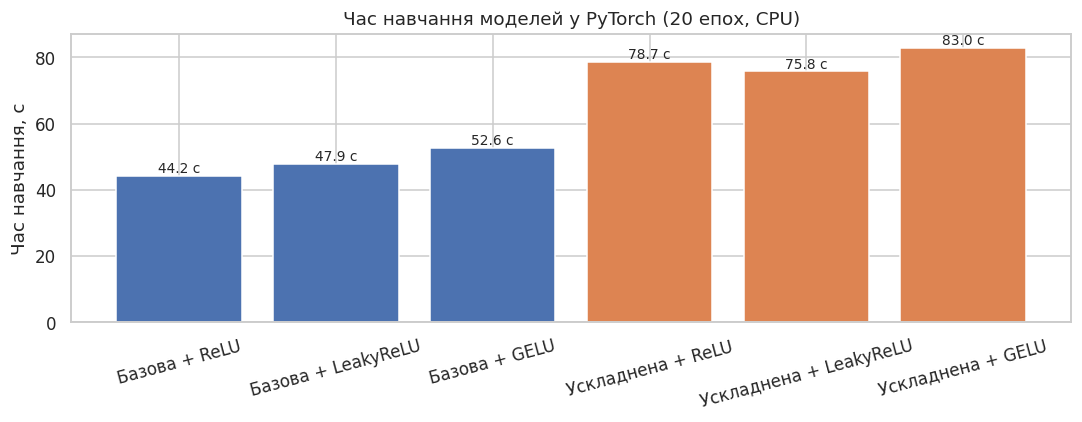

In [33]:
# Таблиця часу: загальний час навчання і середній час на одну епоху
time_df = pd.DataFrame({
    "Загальний час, с": pd.Series(train_times),
    "Час на епоху, с": pd.Series(train_times) / EPOCHS,
})
# Виводимо таблицю
print(time_df.round(2).to_string())

# Стовпчикова діаграма часу навчання кожної моделі
fig, ax = plt.subplots(figsize=(10, 4))
# Колір залежить від архітектури: синій - базова, помаранчевий - ускладнена
colors = ["#4C72B0" if k.startswith("Базова") else "#DD8452" for k in time_df.index]
# Малюємо стовпчики
bars = ax.bar(time_df.index, time_df["Загальний час, с"], color=colors)
# Підписуємо час над кожним стовпчиком
ax.bar_label(bars, fmt="%.1f с", fontsize=9)
# Підпис осі Y і заголовок графіка
ax.set_ylabel("Час навчання, с")
ax.set_title(f"Час навчання моделей у PyTorch ({EPOCHS} епох, CPU)")
# Нахиляємо підписи моделей, щоб вони не накладались
ax.tick_params(axis="x", rotation=15)
# Вирівнюємо відступи та відображаємо графік
fig.tight_layout()
plt.show()

In [34]:
# Метрики якості з бібліотеки scikit-learn
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# Словники для збереження ймовірностей і прогнозів кожної моделі (знадобляться для графіків)
test_proba = {}
test_pred = {}
# Список рядків таблиці метрик
rows = []

# Оцінюємо кожну навчену модель на тестовій вибірці, яку вона ще не бачила
for key, model in trained_models.items():
    # Ймовірність класу satisfied для кожного запису test (функція з пункту 7:
    # режим eval() - Dropout вимкнено, без обчислення градієнтів)
    proba = predict_proba(model, X_test_t)
    # Перетворюємо ймовірність у клас за порогом 0.5
    pred = (proba >= 0.5).astype(int)
    # Зберігаємо ймовірності та прогнози моделі
    test_proba[key] = proba
    test_pred[key] = pred
    # Обчислюємо метрики і додаємо рядок у таблицю
    rows.append({
        "Модель": key,
        "Accuracy": accuracy_score(y_test, pred),                    # частка всіх правильних прогнозів
        "Balanced accuracy": balanced_accuracy_score(y_test, pred),  # середній recall обох класів, стійка до дисбалансу
        "Precision": precision_score(y_test, pred),                  # частка справді задоволених серед спрогнозованих задоволеними
        "Recall": recall_score(y_test, pred),                        # частка знайдених задоволених серед усіх задоволених
        "F1": f1_score(y_test, pred),                                # гармонійне середнє precision і recall
        "ROC-AUC": roc_auc_score(y_test, proba),                     # якість розділення класів за ймовірностями
    })

# Формуємо таблицю, переводимо значення у відсотки і виводимо її
test_results = pd.DataFrame(rows).set_index("Модель") * 100
print(f"Метрики на тестовій вибірці ({len(y_test)} записів), %:")
print(test_results.round(2).to_string())

# Визначаємо найкращу модель за F1 та за ROC-AUC
best_f1 = test_results["F1"].idxmax()
best_auc = test_results["ROC-AUC"].idxmax()
print(f"\nНайкраща модель за F1: {best_f1} ({test_results.loc[best_f1, 'F1']:.2f}%)")
print(f"Найкраща модель за ROC-AUC: {best_auc} ({test_results.loc[best_auc, 'ROC-AUC']:.2f}%)")

Метрики на тестовій вибірці (15586 записів), %:
                        Accuracy  Balanced accuracy  Precision  Recall     F1  ROC-AUC
Модель                                                                                
Базова + ReLU              95.68              95.50      95.74   94.21  94.97    99.27
Базова + LeakyReLU         95.85              95.68      95.92   94.43  95.17    99.39
Базова + GELU              95.98              95.85      95.87   94.82  95.34    99.37
Ускладнена + ReLU          96.19              96.02      96.43   94.71  95.56    99.46
Ускладнена + LeakyReLU     95.99              95.81      96.20   94.48  95.33    99.43
Ускладнена + GELU          96.16              95.96      96.65   94.42  95.52    99.46

Найкраща модель за F1: Ускладнена + ReLU (95.56%)
Найкраща модель за ROC-AUC: Ускладнена + ReLU (99.46%)


In [35]:
# Функція формує звіт з precision, recall і F1 окремо для кожного класу
from sklearn.metrics import classification_report

# Виводимо назву найкращої моделі за F1
print(f"Детальний звіт класифікації для моделі: {best_f1}\n")
# Звіт по обох класах + середні значення (macro і weighted), 4 знаки після коми
print(classification_report(y_test, test_pred[best_f1],
                            target_names=["neutral or dissatisfied", "satisfied"],
                            digits=4))

Детальний звіт класифікації для моделі: Ускладнена + ReLU

                         precision    recall  f1-score   support

neutral or dissatisfied     0.9601    0.9732    0.9666      8832
              satisfied     0.9643    0.9471    0.9556      6754

               accuracy                         0.9619     15586
              macro avg     0.9622    0.9602    0.9611     15586
           weighted avg     0.9619    0.9619    0.9618     15586



                          TN   FP   FN    TP  Помилок усього
Модель                                                      
Базова + ReLU           8549  283  391  6363             674
Базова + LeakyReLU      8561  271  376  6378             647
Базова + GELU           8556  276  350  6404             626
Ускладнена + ReLU       8595  237  357  6397             594
Ускладнена + LeakyReLU  8580  252  373  6381             625
Ускладнена + GELU       8611  221  377  6377             598


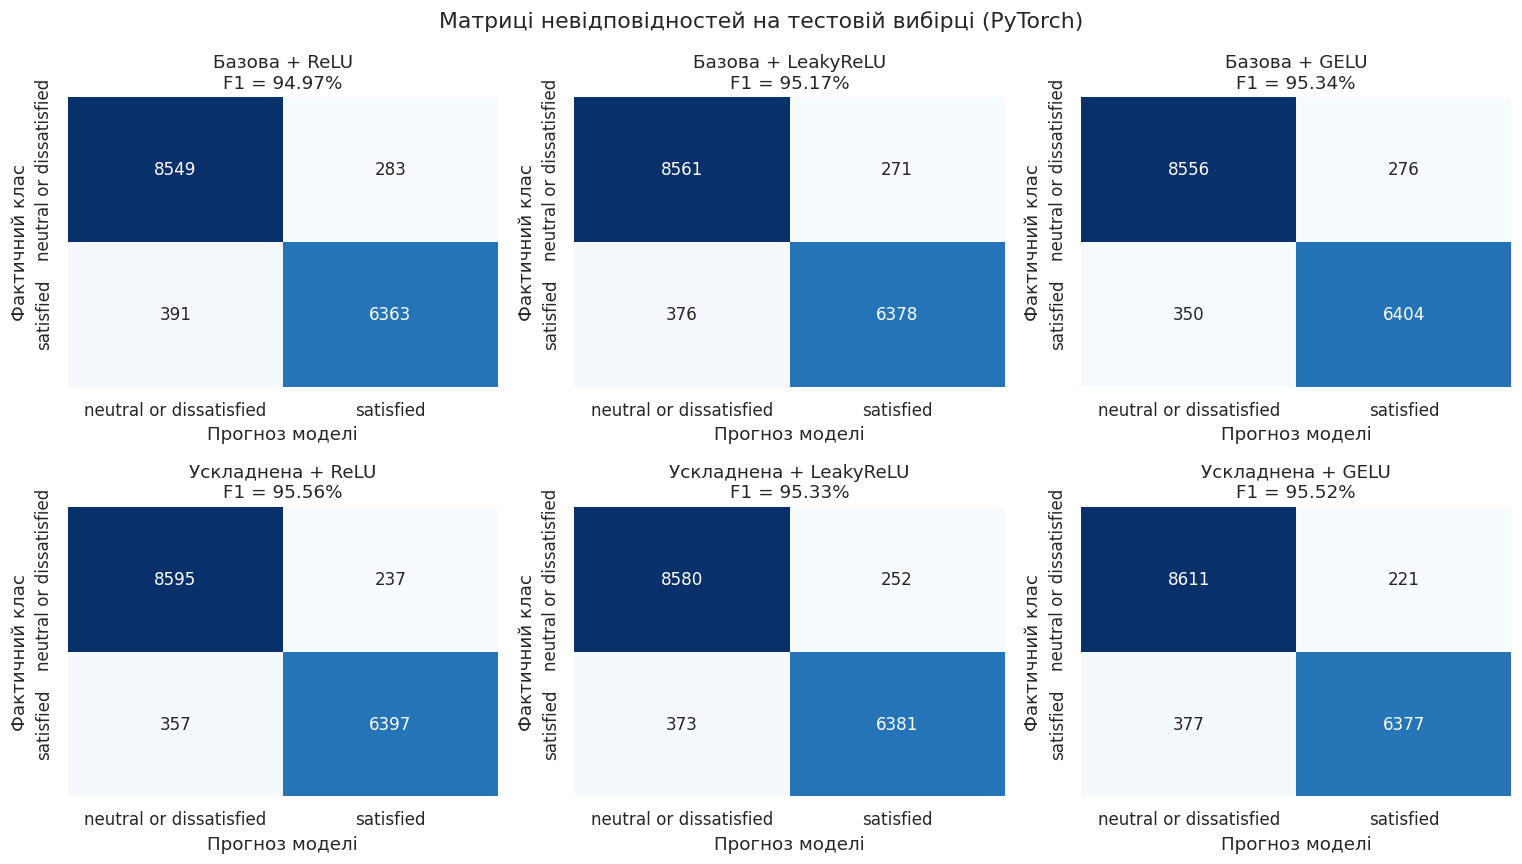

In [36]:
# Функція будує матрицю невідповідностей (confusion matrix)
from sklearn.metrics import confusion_matrix

# Таблиця з кількістю правильних і хибних прогнозів кожної моделі
cm_rows = []
for key in test_pred:
    # TN - правильно визначені незадоволені, FP - незадоволені, помилково названі задоволеними,
    # FN - задоволені, помилково названі незадоволеними, TP - правильно визначені задоволені
    tn, fp, fn, tp = confusion_matrix(y_test, test_pred[key]).ravel()
    cm_rows.append({"Модель": key, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                    "Помилок усього": fp + fn})
# Виводимо таблицю
print(pd.DataFrame(cm_rows).set_index("Модель").to_string())

# Сітка 2 x 3: по одній матриці для кожної моделі
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, key in zip(axes.ravel(), test_pred.keys()):
    # Матриця невідповідностей поточної моделі
    cm = confusion_matrix(y_test, test_pred[key])
    # Теплова карта з кількістю записів у кожній клітинці
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["neutral or dissatisfied", "satisfied"],
                yticklabels=["neutral or dissatisfied", "satisfied"],
                annot_kws={"size": 11})
    # Заголовок з назвою моделі та її F1
    ax.set_title(f"{key}\nF1 = {test_results.loc[key, 'F1']:.2f}%")
    # Підписи осей
    ax.set_xlabel("Прогноз моделі")
    ax.set_ylabel("Фактичний клас")
# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Матриці невідповідностей на тестовій вибірці (PyTorch)")
fig.tight_layout()
plt.show()

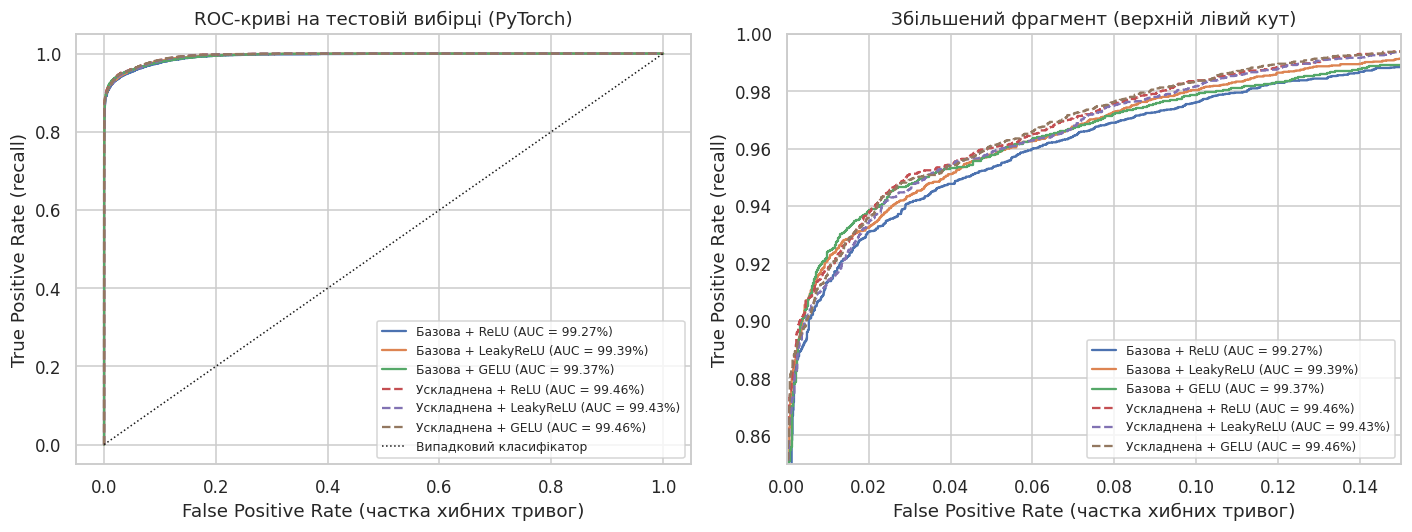

In [37]:
# Функція обчислює точки ROC-кривої
from sklearn.metrics import roc_curve

# Два графіки: повна ROC-крива і збільшений верхній лівий кут
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for key, proba in test_proba.items():
    # FPR - частка хибних тривог, TPR - частка знайдених задоволених при різних порогах
    fpr, tpr, _ = roc_curve(y_test, proba)
    # Базові моделі - суцільна лінія, ускладнені - пунктир
    style = "-" if key.startswith("Базова") else "--"
    # Малюємо криву на обох графіках
    for ax in axes:
        ax.plot(fpr, tpr, linestyle=style, linewidth=1.5,
                label=f"{key} (AUC = {test_results.loc[key, 'ROC-AUC']:.2f}%)")

# Діагональ - ROC-крива випадкового класифікатора (AUC = 50%)
axes[0].plot([0, 1], [0, 1], "k:", linewidth=1, label="Випадковий класифікатор")
axes[0].set_title("ROC-криві на тестовій вибірці (PyTorch)")
# На другому графіку збільшуємо зону, де криві відрізняються
axes[1].set_xlim(0, 0.15)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_title("Збільшений фрагмент (верхній лівий кут)")
# Підписи осей і легенда для обох графіків
for ax in axes:
    ax.set_xlabel("False Positive Rate (частка хибних тривог)")
    ax.set_ylabel("True Positive Rate (recall)")
    ax.legend(fontsize=8, loc="lower right")
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

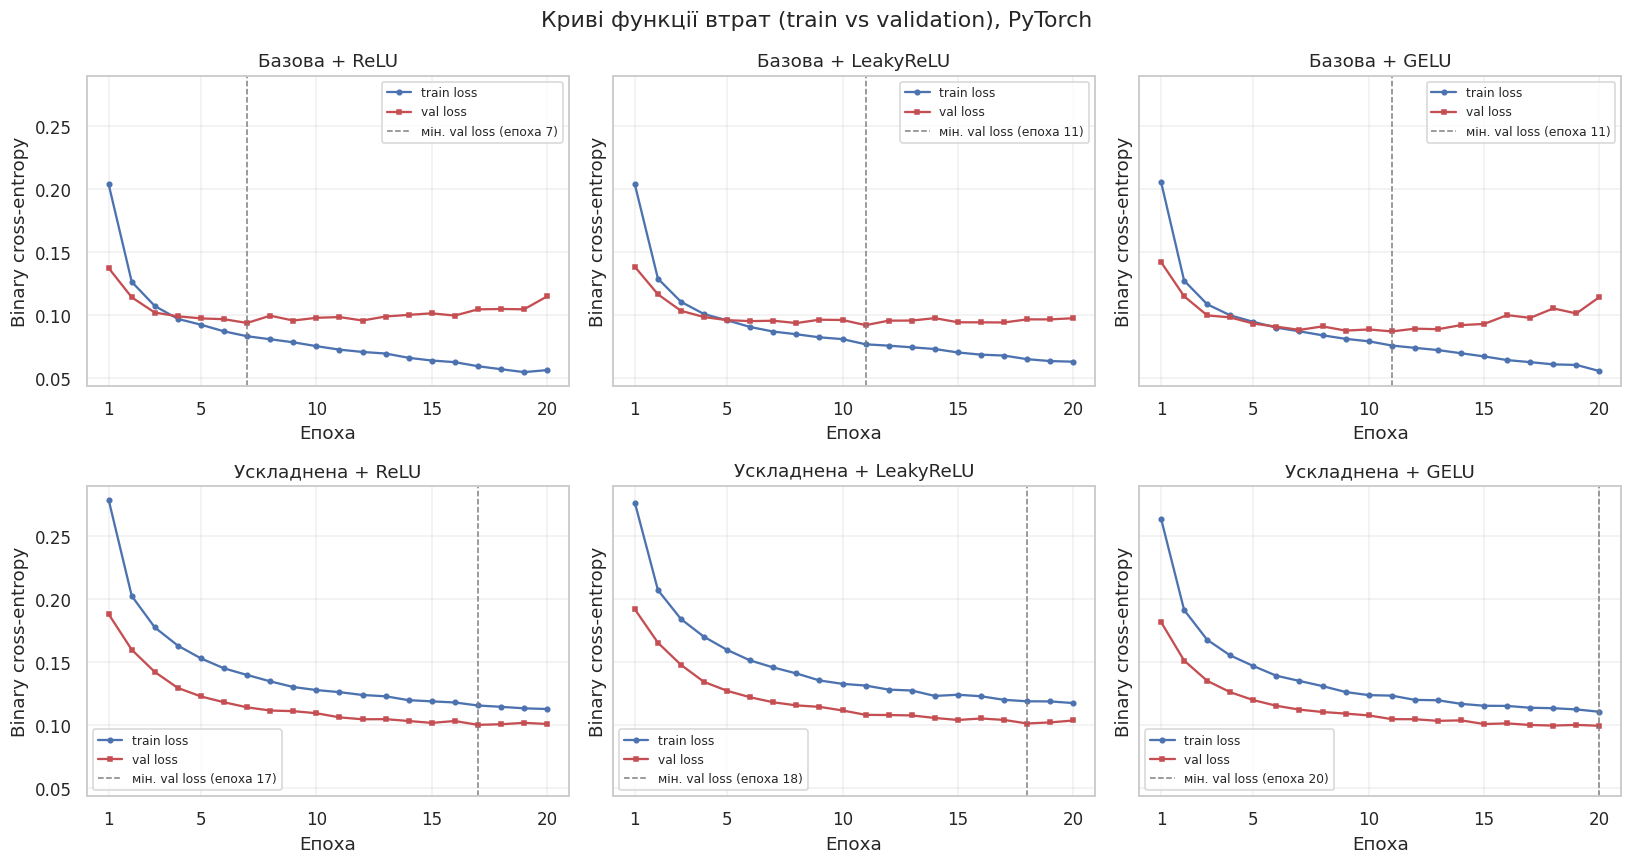

In [38]:
# Номери епох для осі X: від 1 до 20
epochs_range = range(1, EPOCHS + 1)
# Позначки на осі X: 1, 5, 10, 15, 20
ticks = [1] + list(range(5, EPOCHS + 1, 5))

# Сітка 2 x 3: верхній ряд - базові мережі, нижній - ускладнені; спільна вісь Y для порівняння
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, (key, h) in zip(axes.ravel(), histories.items()):
    # Втрати на навчальній вибірці по епохах
    ax.plot(epochs_range, h["loss"], "o-", markersize=3, color="#4C72B0", label="train loss")
    # Втрати на валідаційній вибірці по епохах
    ax.plot(epochs_range, h["val_loss"], "s-", markersize=3, color="#C44E52", label="val loss")
    # Епоха, на якій валідаційні втрати мінімальні (найкращий стан моделі)
    best_ep = int(np.argmin(h["val_loss"])) + 1
    # Позначаємо цю епоху вертикальною пунктирною лінією
    ax.axvline(best_ep, color="gray", linestyle="--", linewidth=1,
               label=f"мін. val loss (епоха {best_ep})")
    # Заголовок, підписи осей і позначки епох
    ax.set_title(key)
    ax.set_xlabel("Епоха")
    ax.set_ylabel("Binary cross-entropy")
    ax.set_xticks(ticks)
    # Легенда і сітка
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Криві функції втрат (train vs validation), PyTorch")
fig.tight_layout()
plt.show()

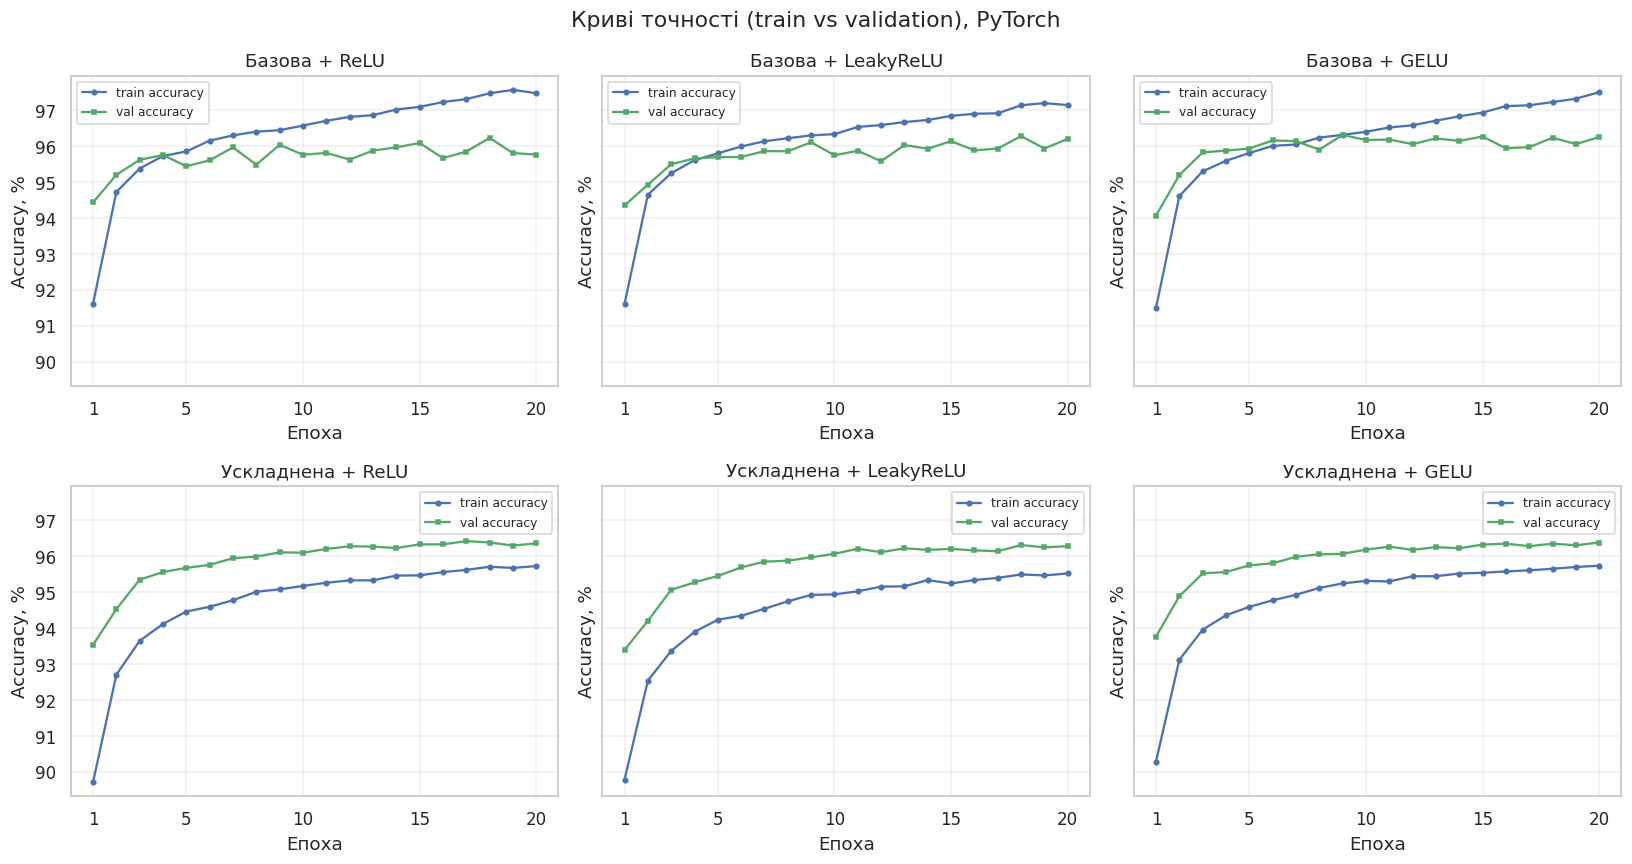

In [39]:
# Сітка 2 x 3 зі спільною віссю Y
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, (key, h) in zip(axes.ravel(), histories.items()):
    # Точність на навчальній вибірці, у відсотках
    ax.plot(epochs_range, np.array(h["accuracy"]) * 100, "o-", markersize=3,
            color="#4C72B0", label="train accuracy")
    # Точність на валідаційній вибірці, у відсотках
    ax.plot(epochs_range, np.array(h["val_accuracy"]) * 100, "s-", markersize=3,
            color="#55A868", label="val accuracy")
    # Заголовок, підписи осей і позначки епох
    ax.set_title(key)
    ax.set_xlabel("Епоха")
    ax.set_ylabel("Accuracy, %")
    ax.set_xticks(ticks)
    # Легенда і сітка
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Криві точності (train vs validation), PyTorch")
fig.tight_layout()
plt.show()

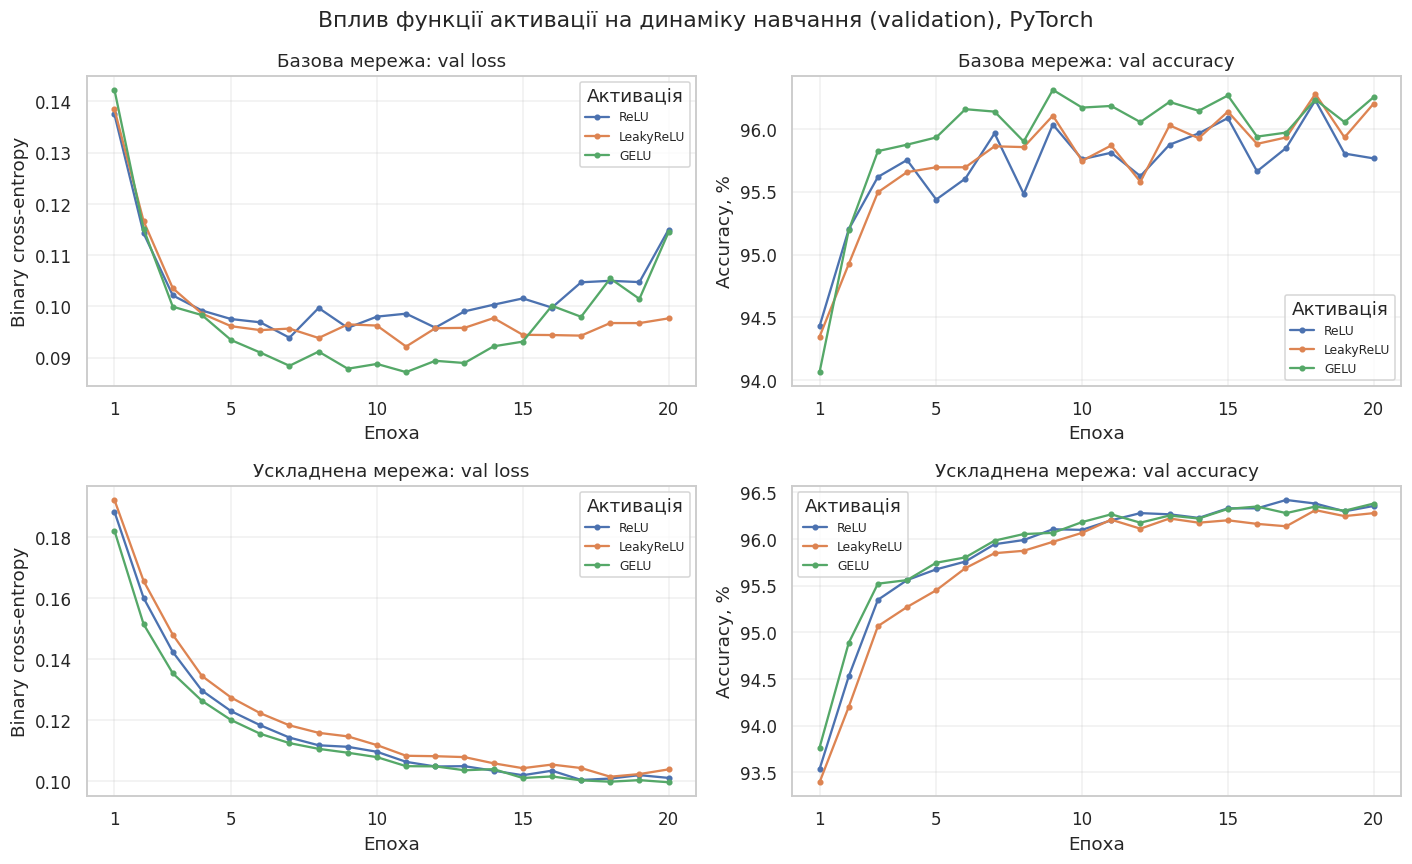

In [40]:
# Кольори для кожної функції активації
act_colors = {"ReLU": "#4C72B0", "LeakyReLU": "#DD8452", "GELU": "#55A868"}

# Сітка 2 x 2: рядки - архітектури, стовпці - val loss і val accuracy
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, arch in enumerate(["Базова", "Ускладнена"]):
    for act, color in act_colors.items():
        # Історія навчання моделі з цією архітектурою та активацією
        h = histories[f"{arch} + {act}"]
        # Лівий графік: валідаційні втрати
        axes[row, 0].plot(epochs_range, h["val_loss"], "o-", markersize=3,
                          color=color, label=act)
        # Правий графік: валідаційна точність у відсотках
        axes[row, 1].plot(epochs_range, np.array(h["val_accuracy"]) * 100, "o-",
                          markersize=3, color=color, label=act)
    # Заголовки та підписи осі Y для рядка
    axes[row, 0].set_title(f"{arch} мережа: val loss")
    axes[row, 0].set_ylabel("Binary cross-entropy")
    axes[row, 1].set_title(f"{arch} мережа: val accuracy")
    axes[row, 1].set_ylabel("Accuracy, %")
    # Спільне оформлення обох графіків рядка
    for ax in axes[row]:
        ax.set_xlabel("Епоха")
        ax.set_xticks(ticks)
        ax.legend(title="Активація", fontsize=8)
        ax.grid(alpha=0.3)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Вплив функції активації на динаміку навчання (validation), PyTorch")
fig.tight_layout()
plt.show()

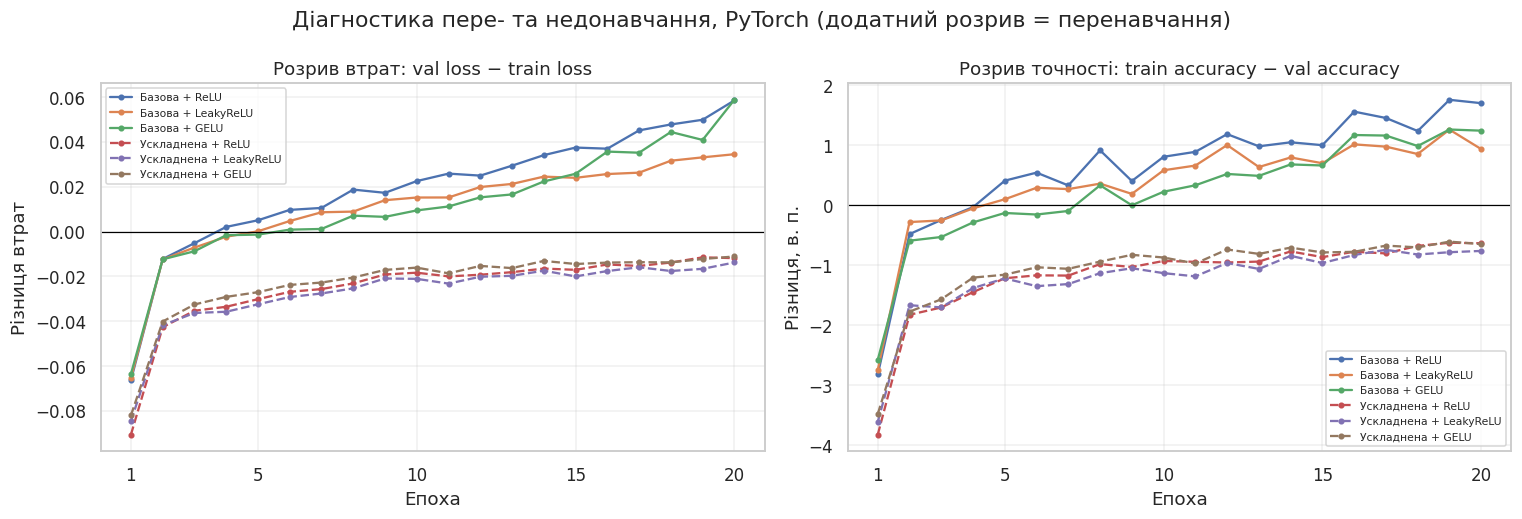

                        Епоха мін. val loss  Мін. val loss  Val loss (кінець)  Зростання val loss, %  Розрив loss (кінець)  Розрив acc, в. п. (кінець)
Модель                                                                                                                                                
Базова + ReLU                             7         0.0939             0.1150                22.4771                0.0585                      1.7052
Базова + LeakyReLU                       11         0.0922             0.0977                 5.9697                0.0345                      0.9389
Базова + GELU                            11         0.0872             0.1145                31.3415                0.0588                      1.2466
Ускладнена + ReLU                        17         0.1005             0.1011                 0.6637               -0.0119                     -0.6308
Ускладнена + LeakyReLU                   18         0.1015             0.1039                 

In [41]:
# Два графіки: розрив втрат і розрив точності між train та validation
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for key, h in histories.items():
    # Базові моделі - суцільна лінія, ускладнені - пунктир
    style = "-" if key.startswith("Базова") else "--"
    # Розрив втрат: наскільки val loss більший за train loss
    loss_gap = np.array(h["val_loss"]) - np.array(h["loss"])
    # Розрив точності: наскільки train accuracy більша за val accuracy, у в. п.
    acc_gap = (np.array(h["accuracy"]) - np.array(h["val_accuracy"])) * 100
    # Малюємо обидва розриви
    axes[0].plot(epochs_range, loss_gap, linestyle=style, marker="o", markersize=3, label=key)
    axes[1].plot(epochs_range, acc_gap, linestyle=style, marker="o", markersize=3, label=key)

# Заголовки та підписи осі Y
axes[0].set_title("Розрив втрат: val loss − train loss")
axes[0].set_ylabel("Різниця втрат")
axes[1].set_title("Розрив точності: train accuracy − val accuracy")
axes[1].set_ylabel("Різниця, в. п.")
# Спільне оформлення: нульова лінія, осі, легенда, сітка
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Епоха")
    ax.set_xticks(ticks)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Діагностика пере- та недонавчання, PyTorch (додатний розрив = перенавчання)")
fig.tight_layout()
plt.show()

# Таблиця з кількісними ознаками перенавчання для кожної моделі
gap_rows = []
for key, h in histories.items():
    gap_rows.append({
        "Модель": key,
        "Епоха мін. val loss": int(np.argmin(h["val_loss"])) + 1,             # найкраща епоха
        "Мін. val loss": min(h["val_loss"]),                                  # найкращі втрати
        "Val loss (кінець)": h["val_loss"][-1],                               # втрати на 20-й епосі
        "Зростання val loss, %": (h["val_loss"][-1] / min(h["val_loss"]) - 1) * 100,  # наскільки погіршились
        "Розрив loss (кінець)": h["val_loss"][-1] - h["loss"][-1],            # розрив втрат на 20-й епосі
        "Розрив acc, в. п. (кінець)": (h["accuracy"][-1] - h["val_accuracy"][-1]) * 100,  # розрив точності
    })
# Виводимо таблицю
print(pd.DataFrame(gap_rows).set_index("Модель").round(4).to_string())

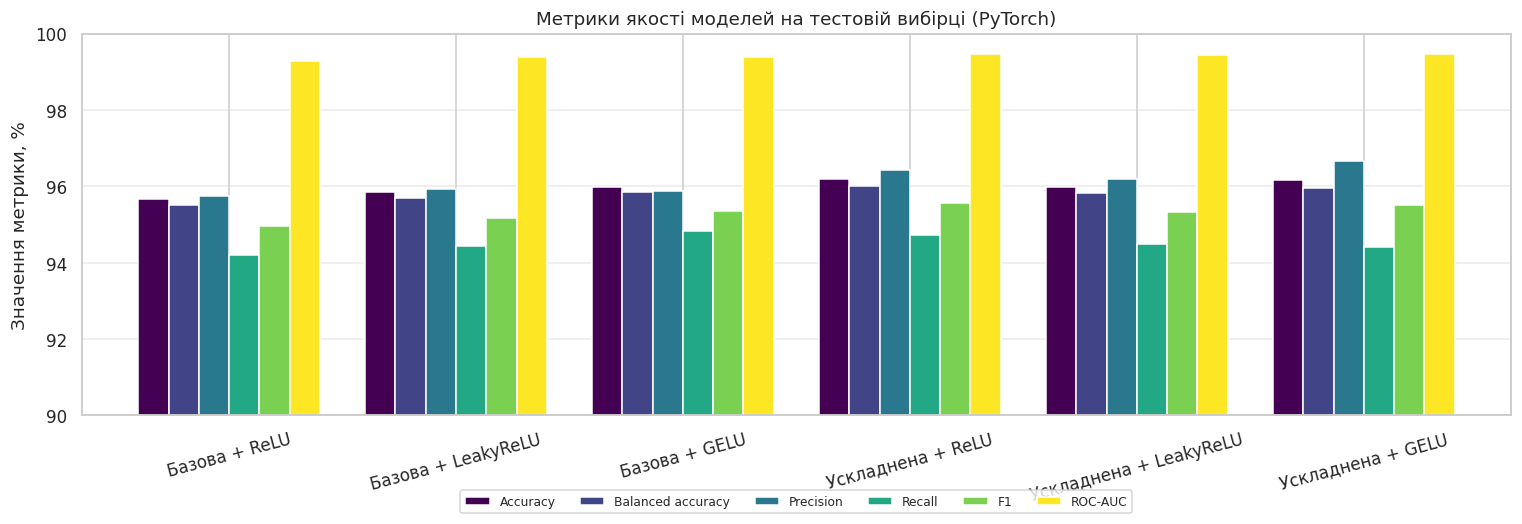

In [42]:
# Метрики, які відображаємо на графіку (обчислені в пункті 9)
metric_cols = ["Accuracy", "Balanced accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

# Згрупована стовпчикова діаграма: для кожної моделі - 6 стовпців метрик
ax = test_results[metric_cols].plot(kind="bar", figsize=(14, 5), width=0.8,
                                    colormap="viridis", edgecolor="white")
# Звужуємо діапазон осі Y, щоб різницю між моделями було видно
ax.set_ylim(90, 100)
# Підписи осей і заголовок
ax.set_ylabel("Значення метрики, %")
ax.set_xlabel("")
ax.set_title("Метрики якості моделей на тестовій вибірці (PyTorch)")
# Нахиляємо назви моделей, щоб вони не накладались
ax.tick_params(axis="x", rotation=15)
# Легенду розміщуємо під графіком в один рядок
ax.legend(ncol=6, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
# Горизонтальна сітка
ax.grid(axis="y", alpha=0.4)
# Вирівнюємо відступи та відображаємо графік
plt.tight_layout()
plt.show()